# Spam Email Classifier
### Naive Bayes Text Classification

**Dataset:** [Spam Email Classification Dataset](https://www.kaggle.com/datasets/purusinghvi/email-spam-classification-dataset) a combined corpus built from the 2007 TREC Public Spam Corpus and the Enron-Spam Dataset.
Two columns: `text` (raw email content) and `label` (`1` = spam, `0` = ham).

---

### What this notebook does

| § | Section | Question it answers |
|---|---------|---------------------|
| 1 | EDA + Preprocessing | What is actually in this corpus, and what should be stripped out? |
| 2 | Baseline model | What does an unconstrained bag of words Naive Bayes overfit look like? |
| 3 | Vectorization comparison | Bag of Words vs TF IDF and raw vs cleaned text |
| 4 | Hyperparameter tuning | `GridSearchCV` over vocabulary size, n-grams and smoothing |
| 5 | Vocabulary cutting | `SelectKBest(chi2)` how few words can we get away with? |
| 6 | Feature importance | Which words does the model consider "spammy"? |
| 7 | Explainability | Word by word decomposition of one single prediction |
| 8 | Bonus | Adversarial obfuscation (`free` → `fr33`) and how to defend against it |

### The one thing to remember here is that
In spam filtering the two errors are **not** equally costly. Spam that lands in the inbox is annoying, but a real email silently moved to the junk folder can be missed entirely. So throughout this notebook I care less about raw accuracy and more about **false positives (ham classified as spam)** reported as precision on the spam class.

## Setup

In [ ]:
import re
import gc
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import (
    CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
)
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.titleweight"] = "bold"

HAM_C, SPAM_C = "#4C9F70", "#D1495B"   

DATA_PATH = "/mnt/user-data/uploads/combined_data.csv"   

print("Libraries loaded.")

Libraries loaded.


---
# 1. EDA + Preprocessing

## 1.1 First look to confirm the split

In [46]:
DATA_PATH = "/content/combined_data.csv"
df = pd.read_csv(DATA_PATH)
df["text"] = df["text"].astype(str)

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nMissing values:\n", df.isna().sum())
print("\nClass counts:\n", df["label"].value_counts())
print("\nClass proportions:\n", df["label"].value_counts(normalize=True).round(4))
df.head(3)

Shape: (83448, 2)

Columns: ['label', 'text']

Missing values:
 label    0
text     0
dtype: int64

Class counts:
 label
1    43910
0    39538
Name: count, dtype: int64

Class proportions:
 label
1    0.5262
0    0.4738
Name: proportion, dtype: float64


,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...


**83,448 emails, 52.6% spam / 47.4% ham.** So this dataset is only mildly imbalanced, far less than a typical churn dataset. This matters for how we read the metrics:

* A majority class only classifier would score **~52.6% accuracy** so accuracy is not completely meaningless here but it still hides which class we are failing on.
* Because the cost of the two errors is wildly asymmetric we will always report **precision / recall / F1 per class** and not accuracy alone.

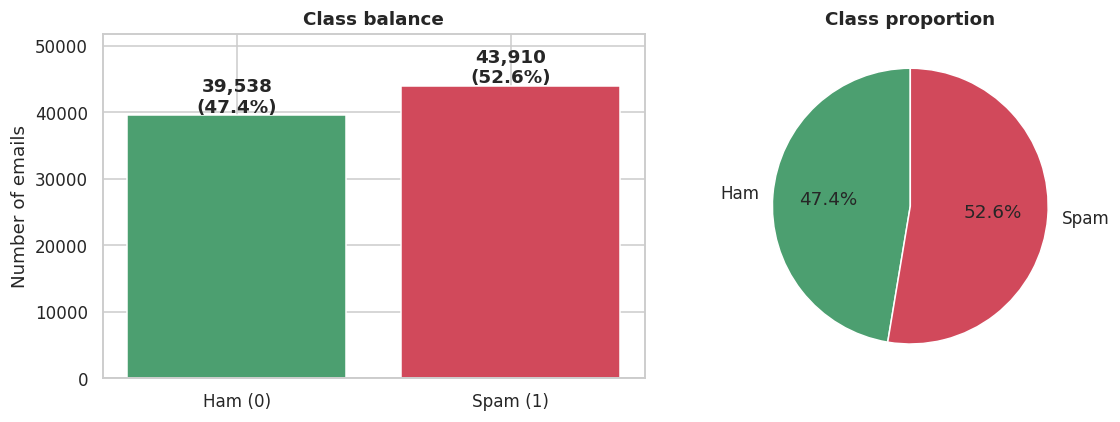

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = df["label"].value_counts().sort_index()
axes[0].bar(["Ham (0)", "Spam (1)"], counts.values, color=[HAM_C, SPAM_C])
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f"{v:,}\n({v/len(df):.1%})", ha="center", fontweight="bold")
axes[0].set_title("Class balance")
axes[0].set_ylabel("Number of emails")
axes[0].set_ylim(0, counts.max() * 1.18)

axes[1].pie(counts.values, labels=["Ham", "Spam"], colors=[HAM_C, SPAM_C],
            autopct="%1.1f%%", startangle=90, wedgeprops={"edgecolor": "white"})
axes[1].set_title("Class proportion")

plt.tight_layout()
plt.show()

## 1.2 Email length: do spam and ham look different before we model anything?

label                 0         1
n_chars count   39538.0   43910.0
        mean     2121.7    1249.9
        std      5666.1    1978.6
        min         1.0       1.0
        25%       579.0     360.0
        50%      1139.0     704.0
        75%      2174.0    1510.0
        max    598705.0  144087.0
n_words count   39538.0   43910.0
        mean      365.1     208.8
        std       984.3     338.3
        min         1.0       1.0
        25%       106.0      61.0
        50%       200.0     122.0
        75%       378.0     249.0
        max    101984.0   25393.0


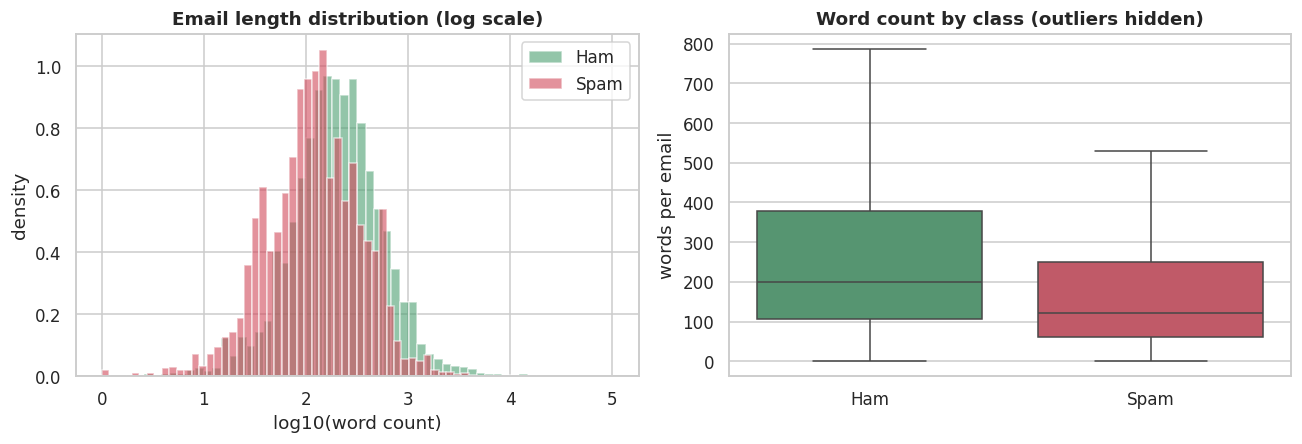


Median words — ham: 200 | spam: 122


In [48]:
df["n_chars"] = df["text"].str.len()
df["n_words"] = df["text"].str.split().str.len()

print(df.groupby("label")[["n_chars", "n_words"]].describe().T.round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

for lbl, name, c in [(0, "Ham", HAM_C), (1, "Spam", SPAM_C)]:
    axes[0].hist(np.log10(df.loc[df.label == lbl, "n_words"].clip(lower=1)),
                 bins=60, alpha=0.6, label=name, color=c, density=True)
axes[0].set_xlabel("log10(word count)")
axes[0].set_ylabel("density")
axes[0].set_title("Email length distribution (log scale)")
axes[0].legend()

sns.boxplot(data=df, x="label", y="n_words", hue="label", legend=False,
            palette=[HAM_C, SPAM_C], showfliers=False, ax=axes[1])
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(["Ham", "Spam"])
axes[1].set_title("Word count by class (outliers hidden)")
axes[1].set_xlabel(""); axes[1].set_ylabel("words per email")

plt.tight_layout()
plt.show()

print(f"\nMedian words — ham: {df[df.label==0].n_words.median():.0f} | "
      f"spam: {df[df.label==1].n_words.median():.0f}")

Spam is noticeably **shorter** on average (median ~122 words vs ~200 for ham), but the distributions overlap heavily, so length alone is a weak signal. The tail is extreme since the longest email is ~100,000 words. Those giants are almost always forwarded message chains or attachment dumps.

## 1.3 Duplicates and near duplicates

This dataset has two datasets glued together and spam is sent from **templates** so we should expect repetition. Exact duplicates that land on both sides of the train/test split are a form of **leakage** as the model gets to memorise a test email during training.

In [49]:
norm = df["text"].str.replace(r"\s+", " ", regex=True).str.strip()

exact_dupes      = df["text"].duplicated().sum()
whitespace_dupes = norm.duplicated().sum()
template_dupes   = norm.str[:100].duplicated().sum()   # same opening = same template

print(f"Exact duplicate texts...................... {exact_dupes:,}")
print(f"Duplicates after whitespace normalisation... {whitespace_dupes:,}")
print(f"Rows sharing their first 100 characters.... {template_dupes:,}  "
      f"({template_dupes/len(df):.1%} of the corpus)")

top_templates = norm.str[:80].value_counts().head(5)
print("\nMost repeated email openings:")
for opening, n in top_templates.items():
    print(f"  {n:>5}x | {opening[:75]!r}")

Exact duplicate texts...................... 2
Duplicates after whitespace normalisation... 418
Rows sharing their first 100 characters.... 21,372  (25.6% of the corpus)

Most repeated email openings:
    499x | 'revno escapenumber revision id tridge samba org escapenumber escapelong par'
    414x | 'while we may have high expectations of our associates we also give them hig'
    355x | 'dear sirs aegis capital group llc \x93aegis\x94 is a specialty investment firm ma'
    334x | 'author metze date escapenumber escapenumber escapenumber escapenumber escap'
    255x | 'subscribe change profile contact us long term escapenumber day trend weathe'


Only 418 rows are exact byte-for-byte duplicates. **But 26% of rows share an opening with another row**. This is the templated spam problem the brief warns about.

We decided to drop exact duplicates after whitespace normalization but keep the near duplicates. Why:
* Exact duplicates add nothing new and can leak across the split. So we remove them.
* Near duplicate templates are realistic. Spammers send the same template with small changes. A real filter sees this. If we removed them, our test set would be easier than reality, not harder.
* The test scores are a bit optimistic because some test emails have near twins in training.

In [50]:
before = len(df)
df = df.loc[~norm.duplicated()].reset_index(drop=True)
print(f"Dropped {before - len(df):,} duplicate rows  →  {len(df):,} emails remain")
print(df["label"].value_counts(normalize=True).round(4).to_string())

Dropped 418 duplicate rows  →  83,030 emails remain
label
1    0.5277
0    0.4723


## 1.4 Artifact audit: what junk is actually in the text?

Before writing a cleaning function we need to look at what needs cleaning rather than guessing. For each candidate junk token we report how many emails contain it and what fraction of those are spam (0.5 ≈ uninformative, 0 or 1 ≈ perfectly predictive).

In [51]:
probe = ["escapenumber", "escapelong", "http", "www", "subject", "enron",
         "ect", "hou", "nbsp", "href", "font", "viagra", "free", "click"]

rows = []
for tok in probe:
    mask = df["text"].str.contains(rf"\b{tok}\b", regex=True, na=False)
    rows.append({"token": tok, "n_emails": int(mask.sum()),
                 "pct_of_corpus": mask.mean(), "spam_rate": df.loc[mask, "label"].mean()})

audit = pd.DataFrame(rows).sort_values("n_emails", ascending=False)
audit["pct_of_corpus"] = (audit["pct_of_corpus"] * 100).round(1)
audit["spam_rate"] = audit["spam_rate"].round(3)
print(audit.to_string(index=False))

print("\nAny leftover <html> tags? ", df["text"].str.contains(r"<[a-z/]", regex=True).sum())
print("Any uppercase characters? ", df["text"].str.contains(r"[A-Z]", regex=True).sum())
print("Any digits?               ", df["text"].str.contains(r"[0-9]", regex=True).sum())

       token  n_emails  pct_of_corpus  spam_rate
escapenumber     41855           50.4      0.491
        http     35401           42.6      0.475
         www     18104           21.8      0.364
  escapelong     12886           15.5      0.620
     subject     11610           14.0      0.167
        free      9958           12.0      0.561
       click      8199            9.9      0.635
       enron      6758            8.1      0.000
         ect      3140            3.8      0.008
         hou      2947            3.5      0.013
      viagra      2145            2.6      0.994
        font       596            0.7      0.383
        href       248            0.3      0.673
        nbsp        75            0.1      0.907

Any leftover <html> tags?  0
Any uppercase characters?  0
Any digits?                24177


Three important findings:

1. **The dataset has been partially pre-normalised by whoever built it.** Everything is already lowercase, HTML tags are gone, and numbers have been replaced with the placeholder tokens escapenumber/escapelong. So the lowercase and strip HTML steps mostly do nothing here, but we still write them because they are what we would need on genuinely raw email and they cost nothing.

2. **escapenumber appears in approximately 53% of all emails** with a spam rate of approximately 0.51, it is the noise that dominates the vocabulary.

3. **enron appears in ~7,000 emails and is 100% ham.** This is dataset leakage and not spam signal. The ham half came from the Enron archive, so the word "enron" is really a label for which dataset a message came from. A model that leans on it will score
beautifully here and fall over on the actual inbox. Same thing goes for `ect` and `hou` (Enron internal routing codes). We will put these on a custom list and measure the cost.

In [52]:
for tok in ["enron", "ect", "hou"]:
    m = df["text"].str.contains(rf"\b{tok}\b", regex=True)
    print(f"'{tok}': {m.sum():>6,} emails | spam {df.loc[m,'label'].sum():>5,} "
          f"| ham {(~df.loc[m,'label'].astype(bool)).sum():>6,}")

'enron':  6,758 emails | spam     1 | ham  6,757
'ect':  3,140 emails | spam    24 | ham  3,116
'hou':  2,947 emails | spam    39 | ham  2,908


## 1.5 The cleaning function

We write **one configurable cleaner** rather than three separate ones so that we can measure each preprocessing decision instead of assuming it helps.

| Step | What it does | Why |
|---|---|---|
| lowercase | `FREE` → `free` | `Free`/`FREE`/`free` should be one feature, not three |
| strip HTML tags & entities | `<b>`, `&nbsp;` → ` ` | markup is formatting, not language |
| strip URLs / emails | `http://x.com` → ` ` | every URL is unique → pure vocabulary bloat |
| remove digits & punctuation | `f1ve!` → `f ve` | keeps the vocabulary alphabetic |
| drop tokens < 3 chars | `to`, `hi` | mostly noise once stopwords are gone |
| remove English stopwords | `the`, `and`, `is` | ~40% of tokens, near-zero discriminative power |
| remove corpus artifacts | `escapenumber`, `enron`, `ect` | dataset fingerprints, not spam signal |

In [53]:
URL_RE      = re.compile(r"(?:https?://|www\.)\S+|\S+@\S+\.\S+")
HTML_TAG_RE = re.compile(r"<[^>]{0,200}>")
HTML_ENT_RE = re.compile(r"&[a-z]{2,8};|&#\d{1,5};")
NON_ALPHA   = re.compile(r"[^a-z\s]")
MULTISPACE  = re.compile(r"\s+")
TOKEN_RE    = re.compile(r"\b[a-z]{3,}\b")

# Dataset-specific artifacts found in the audit above
CORPUS_ARTIFACTS = {
    "escapenumber", "escapelong", "escapetoken",   # numeric placeholders
    "enron", "ect", "hou",                         # Enron-corpus fingerprints (leakage!)
    "nbsp", "href", "http", "https", "www",        # markup / URL remnants
}

STOPWORDS = set(ENGLISH_STOP_WORDS)


def clean_email(text,
                remove_stopwords=True,
                remove_artifacts=True,
                min_len=3):
    """Normalise one raw email into a whitespace-joined string of clean tokens."""
    t = text.lower()
    t = HTML_TAG_RE.sub(" ", t)
    t = HTML_ENT_RE.sub(" ", t)
    t = URL_RE.sub(" ", t)
    t = NON_ALPHA.sub(" ", t)          # kills digits + punctuation in one pass
    tokens = TOKEN_RE.findall(t) if min_len == 3 else \
             [w for w in MULTISPACE.sub(" ", t).split() if len(w) >= min_len]

    if remove_stopwords:
        tokens = [w for w in tokens if w not in STOPWORDS]
    if remove_artifacts:
        tokens = [w for w in tokens if w not in CORPUS_ARTIFACTS]
    return " ".join(tokens)


# --- sanity check on a made-up "raw" email -------------------------------------
demo = ("Subject: <b>RE: Your ACCOUNT</b>&nbsp; Click http://cheap-pillz.ru/x?id=42 "
        "NOW!!! We have 100% FREE V1AGRA for you, call 555-0199 — best regards, enron desk")
print("RAW    :", demo)
print("\nCLEANED:", clean_email(demo))

RAW    : Subject: <b>RE: Your ACCOUNT</b>&nbsp; Click http://cheap-pillz.ru/x?id=42 NOW!!! We have 100% FREE V1AGRA for you, call 555-0199 — best regards, enron desk

CLEANED: subject account click free agra best regards desk


In [54]:
t0 = time.time()
df["clean_basic"] = df["text"].apply(
    lambda s: clean_email(s, remove_stopwords=False, remove_artifacts=False))
df["clean_text"] = df["text"].apply(
    lambda s: clean_email(s, remove_stopwords=True, remove_artifacts=True))
print(f"Cleaned {len(df):,} emails in {time.time()-t0:.0f}s")

pd.set_option("display.max_colwidth", 160)
display(df.loc[[1, 2], ["label", "text", "clean_text"]])
pd.reset_option("display.max_colwidth")

Cleaned 83,030 emails in 46s


,label,text,clean_text
1,1,wulvob get your medircations online qnb ikud viagra escapenumber escapenumber levitra escapenumber escapenumber cialis escapenumber escapenumber imitrex esc...,wulvob medircations online qnb ikud viagra levitra cialis imitrex flonax ultram vioxx ambien valium xannax soma meridia cysfrt stopped wonder average man pa...
2,0,computer connection from cnn com wednesday escapenumber may escapenumber escapenumber escapenumber escapenumber pm edt in this report next generation toys ...,computer connection cnn com wednesday edt report generation toys read brain waves google expands personalization youtube wins webby old fashioned rabbit ear...


## 1.6 What did cleaning actually remove?

In [55]:
def vocab_size(series, sample=20000):
    s = series.sample(min(sample, len(series)), random_state=RANDOM_STATE)
    return len(CountVectorizer().fit(s).vocabulary_)

rows = []
for name, col in [("raw text", "text"), ("basic clean", "clean_basic"),
                  ("full clean", "clean_text")]:
    toks = df[col].str.split().str.len()
    rows.append({"version": name,
                 "vocab (20k sample)": vocab_size(df[col]),
                 "total tokens (M)": round(toks.sum() / 1e6, 2),
                 "median tokens/email": int(toks.median())})

shrink = pd.DataFrame(rows)
shrink["tokens kept vs raw"] = (shrink["total tokens (M)"] /
                                shrink["total tokens (M)"].iloc[0]).map("{:.0%}".format)
shrink["vocab kept vs raw"] = (shrink["vocab (20k sample)"] /
                               shrink["vocab (20k sample)"].iloc[0]).map("{:.0%}".format)
print(shrink.to_string(index=False))

    version  vocab (20k sample)  total tokens (M)  median tokens/email tokens kept vs raw vocab kept vs raw
   raw text              142543             23.49                  152               100%              100%
basic clean              127437             17.09                  112                73%               89%
 full clean              127145             10.98                   71                47%               89%


**Short note on what got stripped and why:**

Cleaning throws away roughly **half** the tokens and a large slice of the vocabulary and almost all of it is stuff that cannot help a spam classifier:

* **Stopwords** (`the`, `to`, `and`, …) are ~40% of the token mass and appear at nearly identical rates in spam and ham so they add columns without adding signal.
* **Digits and punctuation** produce huge numbers of one off features (`escapenumber`, phone numbers, message-IDs). Removing them collapses that noise.
* **URLs and markup** are effectively unique per email: pure vocabulary bloat.
* **Dataset artifacts** (`enron`, `ect`, `hou`, `escapenumber`) are removed on purpose even though `enron` is extremely predictive here, because it predicts *which archive the email came from*, not whether it is spam. Keeping it would inflate our test score and destroy real world generalisation. This is the single most important preprocessing judgement call in the whole notebook, and section 3 measures exactly what it costs us.

## 1.7 Stratified train/test split

Stratified so both splits keep the 53/47 class ratio. Split **once**, up front, so every model below sees the same split, so comparisons are apples to apples. The test set is touched only for final reporting and all tuning uses cross validation inside the training set.

In [56]:
X_train_raw, X_test_raw, X_train_basic, X_test_basic, \
X_train_clean, X_test_clean, y_train, y_test = train_test_split(
    df["text"].values, df["clean_basic"].values, df["clean_text"].values, df["label"].values,
    test_size=0.20, random_state=RANDOM_STATE, stratify=df["label"].values
)

print(f"Train: {len(y_train):,}  |  spam rate {y_train.mean():.4f}")
print(f"Test : {len(y_test):,}  |  spam rate {y_test.mean():.4f}")

gc.collect()

Train: 66,424  |  spam rate 0.5277
Test : 16,606  |  spam rate 0.5277


0

---
# 2. Baseline Model: the deliberately unconstrained one

We will fit `MultinomialNB()` (default `alpha=1.0`) on a **completely unconstrained** `CountVectorizer()` applied to the **raw, uncleaned** text:

* `max_features=None`: every unique token in training becomes a feature
* `min_df=1`: including words that appear in exactly one email
* `stop_words=None`: no filtering at all

This is the text classification analogue of growing a decision tree with no depth limit.

In [57]:
RESULTS = []

def evaluate(name, y_tr, p_tr, y_te, p_te, proba_te=None, note="", store=True):
    """Collect train/test metrics for one model and print a compact report."""
    row = {
        "model": name,
        "train_acc": accuracy_score(y_tr, p_tr),
        "test_acc": accuracy_score(y_te, p_te),
        "test_prec_spam": precision_score(y_te, p_te),
        "test_recall_spam": recall_score(y_te, p_te),
        "test_f1_spam": f1_score(y_te, p_te),
        "ham_misfiled(FP)": int(((p_te == 1) & (y_te == 0)).sum()),
        "spam_missed(FN)": int(((p_te == 0) & (y_te == 1)).sum()),
        "note": note,
    }
    row["overfit_gap"] = row["train_acc"] - row["test_acc"]
    if proba_te is not None:
        row["test_auc"] = roc_auc_score(y_te, proba_te)
    if store:
        RESULTS.append(row)
    print(f"── {name} ──")
    print(f"   train accuracy : {row['train_acc']:.4f}")
    print(f"   test  accuracy : {row['test_acc']:.4f}   (gap {row['overfit_gap']:+.4f})")
    print(f"   spam precision : {row['test_prec_spam']:.4f}   "
          f"recall {row['test_recall_spam']:.4f}   F1 {row['test_f1_spam']:.4f}")
    print(f"   ham misfiled as spam (FP): {row['ham_misfiled(FP)']}  |  "
          f"spam reaching inbox (FN): {row['spam_missed(FN)']}")
    return row


def plot_cm(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["pred ham", "pred spam"],
                yticklabels=["true ham", "true spam"])
    ax.set_title(title)

In [58]:
t0 = time.time()
baseline_vec = CountVectorizer()
Xtr_base = baseline_vec.fit_transform(X_train_raw)
Xte_base = baseline_vec.transform(X_test_raw)

baseline_nb = MultinomialNB()
baseline_nb.fit(Xtr_base, y_train)

p_tr = baseline_nb.predict(Xtr_base)
p_te = baseline_nb.predict(Xte_base)
proba = baseline_nb.predict_proba(Xte_base)[:, 1]

print(f"Vocabulary size: {len(baseline_vec.vocabulary_):,} features "
      f"(fit in {time.time()-t0:.0f}s)\n")
base_row = evaluate("Baseline: raw text + unconstrained CountVectorizer + NB(alpha=1)",
                    y_train, p_tr, y_test, p_te, proba, note="no constraints at all")

print("\n" + classification_report(y_test, p_te, target_names=["ham", "spam"], digits=4))

Vocabulary size: 276,129 features (fit in 24s)

── Baseline: raw text + unconstrained CountVectorizer + NB(alpha=1) ──
   train accuracy : 0.9818
   test  accuracy : 0.9761   (gap +0.0057)
   spam precision : 0.9858   recall 0.9686   F1 0.9771
   ham misfiled as spam (FP): 122  |  spam reaching inbox (FN): 275

              precision    recall  f1-score   support

         ham     0.9656    0.9844    0.9749      7843
        spam     0.9858    0.9686    0.9771      8763

    accuracy                         0.9761     16606
   macro avg     0.9757    0.9765    0.9760     16606
weighted avg     0.9763    0.9761    0.9761     16606



## 2.1 Why this vocabulary is mostly junk

A useful diagnostic: how many of those features appear in only **one** training email? Those hapax legomena can never generalise; they are memorised trivia.

Total features ................ 276,129
Appear in exactly 1 email ..... 151,493  (54.9%)
Appear in <= 3 emails ......... 202,059  (73.2%)
Appear in >= 50 emails ........ 12,810  (4.6%)


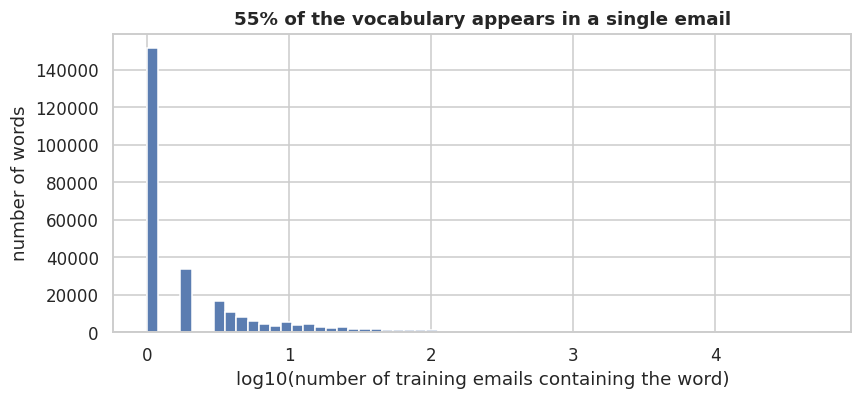

In [59]:
doc_freq = np.asarray((Xtr_base > 0).sum(axis=0)).ravel()
V = len(doc_freq)
hapax = (doc_freq == 1).sum()
rare = (doc_freq <= 3).sum()

print(f"Total features ................ {V:,}")
print(f"Appear in exactly 1 email ..... {hapax:,}  ({hapax/V:.1%})")
print(f"Appear in <= 3 emails ......... {rare:,}  ({rare/V:.1%})")
print(f"Appear in >= 50 emails ........ {(doc_freq>=50).sum():,}  ({(doc_freq>=50).sum()/V:.1%})")

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.hist(np.log10(doc_freq), bins=60, color="#5B7DB1")
ax.set_xlabel("log10(number of training emails containing the word)")
ax.set_ylabel("number of words")
ax.set_title(f"{hapax/V:.0%} of the vocabulary appears in a single email")
plt.tight_layout(); plt.show()

## 2.2 The overfitting demonstration: performance vs. share of unseen vocabulary

The headline train/test gap for Naive Bayes is small as NB is a high bias model and does not overfit as spectacularly as an unpruned tree. The damage shows up somewhere more specific: **on test emails made largely of words the model never saw in training** every one of which the model ignores unknowingly.

We will also compute for each test email the fraction of its tokens that are **out of vocabulary (OOV)** then bucket the test set by that fraction.

         n_emails  accuracy  mean_oov
bucket                               
0-5%        15281    0.9810    0.0059
5-10%         706    0.9292    0.0706
10-20%        367    0.9046    0.1404
20-40%        138    0.9348    0.2750
40-100%       114    0.8860    0.6285


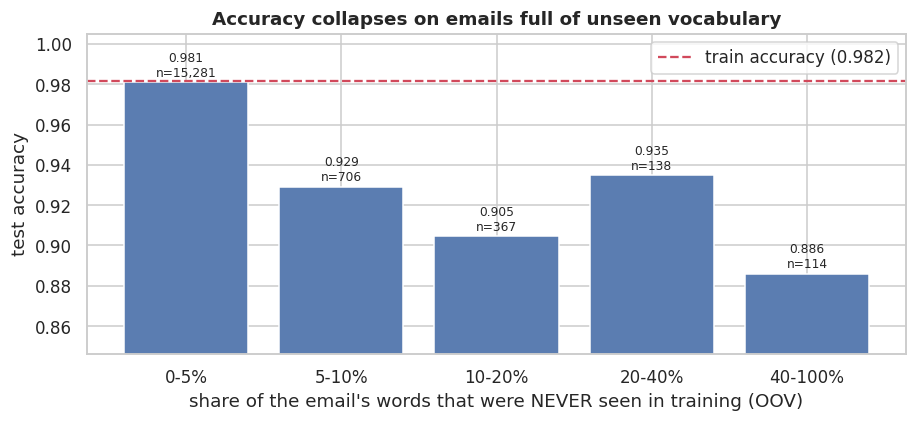

In [60]:
analyzer = baseline_vec.build_analyzer()
vocab = baseline_vec.vocabulary_

oov_frac, n_tok = [], []
for doc in X_test_raw:
    toks = analyzer(doc)
    n_tok.append(len(toks))
    oov_frac.append(np.mean([t not in vocab for t in toks]) if toks else 1.0)

oov = pd.DataFrame({"oov_frac": oov_frac, "n_tokens": n_tok,
                    "y": y_test, "pred": p_te})
oov["correct"] = (oov.y == oov.pred).astype(int)
oov["bucket"] = pd.cut(oov.oov_frac, [-0.001, 0.05, 0.10, 0.20, 0.40, 1.0],
                       labels=["0-5%", "5-10%", "10-20%", "20-40%", "40-100%"])

summary = (oov.groupby("bucket", observed=True)
              .agg(n_emails=("correct", "size"),
                   accuracy=("correct", "mean"),
                   mean_oov=("oov_frac", "mean")).round(4))
print(summary.to_string())

fig, ax = plt.subplots(figsize=(8.5, 4))
bars = ax.bar(summary.index.astype(str), summary["accuracy"], color="#5B7DB1")
ax.axhline(base_row["train_acc"], ls="--", c=SPAM_C,
           label=f"train accuracy ({base_row['train_acc']:.3f})")
ax.set_ylim(min(summary["accuracy"]) - 0.04, 1.005)
ax.set_xlabel("share of the email's words that were NEVER seen in training (OOV)")
ax.set_ylabel("test accuracy")
ax.set_title("Accuracy collapses on emails full of unseen vocabulary")
for b, (v, n) in zip(bars, summary[["accuracy", "n_emails"]].values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.003, f"{v:.3f}\nn={int(n):,}",
            ha="center", fontsize=8)
ax.legend()
plt.tight_layout(); plt.show()

**Reading the result.** The headline train/test gap is small: 0.9818 train vs 0.9761 test. Naive Bayes is a high bias model as it cannot bend itself around the training set the way an unpruned decision tree can so the classic "train 1.00/test 0.75" blow up does not work here.

What the OOV buckets show:

* On emails whose vocabulary the model has essentially all seen before (0 to 5% out of vocabulary, 92% of the test set), accuracy is **0.981**.
* On emails that are 40% plus unseen vocabulary it falls to **0.886** roughly a five-fold increase in error rate.

And the aggregate number is misleading because most test emails fall in the easy bucket. A deployed filter sees far more high Out Of Vocabulary mail than this test set does because new
campaigns, new products and new senders arrive continuously.

Meanwhile **54.9% of the 276,129 features appear in exactly one training email** and **73.2% for three or fewer**. Those features cannot possibly generalise as they are
memorised, and they inflate the model's size without improving its judgement. That is the text classification version of an unpruned tree: not a large overfit, but a model carrying an enormous amount of dead weight.

In [61]:
del Xtr_base, Xte_base, baseline_nb, analyzer, vocab, oov
gc.collect()

14074

---
# 3. Vectorization Comparison between the Bag of Words vs TF-IDF

Two factors vary and everything else is held fixed:

* **preprocessing**: raw vs basic clean (no stopword or artifact removal) vs full clean
* **vectorizer**: `CountVectorizer` (raw counts) vs `TfidfVectorizer` (frequency weighted by inverse document frequency)

The classifier stays `MultinomialNB(alpha=1.0)` and the vectorizers share `max_features=30000, ngram_range=(1,1)` so that the only thing changing is the weighting scheme and the input text.

**What we expect:** TF-IDF down weights words that appear everywhere. That should matter a lot for raw text where escapenumber tokens dominate the counts and much less after
cleaning because we already removed those words by hand.

In [62]:
FIXED = dict(max_features=30000, ngram_range=(1, 1))

texts = {
    "raw":   (X_train_raw, X_test_raw),
    "basic": (X_train_basic, X_test_basic),
    "clean": (X_train_clean, X_test_clean),
}
vecs = {"Count": CountVectorizer, "Tfidf": TfidfVectorizer}

comparison, fitted = [], {}
for tname, (xtr, xte) in texts.items():
    for vname, VecCls in vecs.items():
        vec = VecCls(**FIXED)
        A = vec.fit_transform(xtr)
        B = vec.transform(xte)
        nb = MultinomialNB(alpha=1.0).fit(A, y_train)
        pt, pe = nb.predict(A), nb.predict(B)
        r = evaluate(f"{vname}Vectorizer + {tname} text", y_train, pt, y_test, pe,
                     nb.predict_proba(B)[:, 1], note="fixed 30k unigram features")
        comparison.append({**r, "text": tname, "vec": vname})
        fitted[(tname, vname)] = (vec, nb)
        print()
        del A, B; gc.collect()

comp = pd.DataFrame(comparison)

── CountVectorizer + raw text ──
   train accuracy : 0.9701
   test  accuracy : 0.9688   (gap +0.0013)
   spam precision : 0.9801   recall 0.9604   F1 0.9701
   ham misfiled as spam (FP): 171  |  spam reaching inbox (FN): 347

── TfidfVectorizer + raw text ──
   train accuracy : 0.9768
   test  accuracy : 0.9743   (gap +0.0025)
   spam precision : 0.9824   recall 0.9687   F1 0.9755
   ham misfiled as spam (FP): 152  |  spam reaching inbox (FN): 274

── CountVectorizer + basic text ──
   train accuracy : 0.9658
   test  accuracy : 0.9643   (gap +0.0015)
   spam precision : 0.9788   recall 0.9530   F1 0.9657
   ham misfiled as spam (FP): 181  |  spam reaching inbox (FN): 412

── TfidfVectorizer + basic text ──
   train accuracy : 0.9744
   test  accuracy : 0.9725   (gap +0.0018)
   spam precision : 0.9828   recall 0.9649   F1 0.9737
   ham misfiled as spam (FP): 148  |  spam reaching inbox (FN): 308

── CountVectorizer + clean text ──
   train accuracy : 0.9689
   test  accuracy : 0.9687

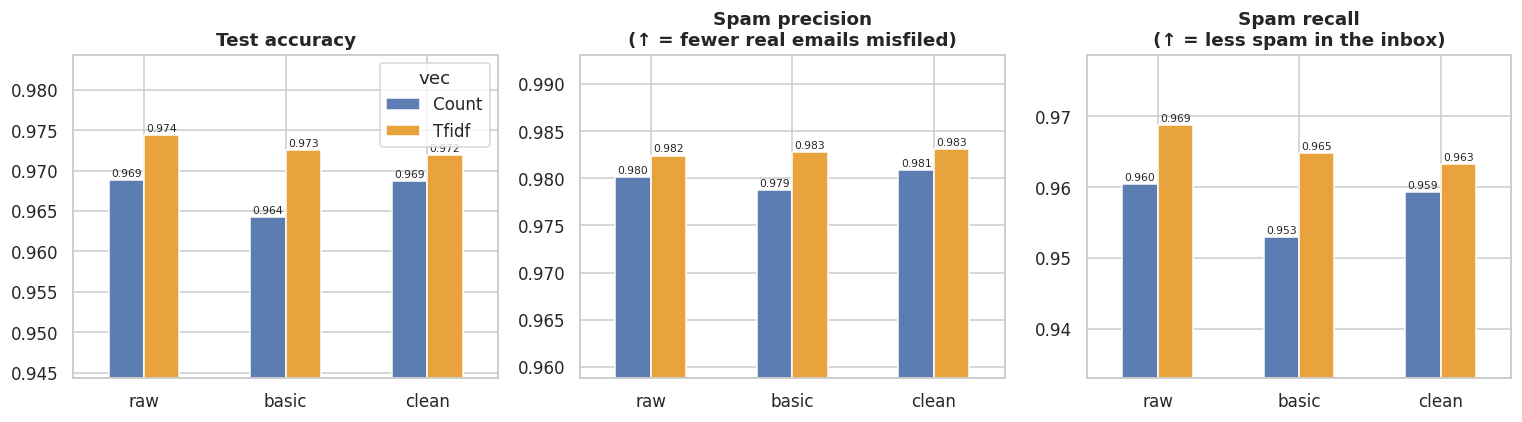

                       model  test_acc  test_prec_spam  test_recall_spam  test_f1_spam  ham_misfiled(FP)  spam_missed(FN)
  CountVectorizer + raw text    0.9688          0.9801            0.9604        0.9701               171              347
  TfidfVectorizer + raw text    0.9743          0.9824            0.9687        0.9755               152              274
CountVectorizer + basic text    0.9643          0.9788            0.9530        0.9657               181              412
TfidfVectorizer + basic text    0.9725          0.9828            0.9649        0.9737               148              308
CountVectorizer + clean text    0.9687          0.9809            0.9594        0.9700               164              356
TfidfVectorizer + clean text    0.9719          0.9831            0.9633        0.9731               145              322


In [63]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, metric, title in zip(
        axes,
        ["test_acc", "test_prec_spam", "test_recall_spam"],
        ["Test accuracy", "Spam precision\n(↑ = fewer real emails misfiled)",
         "Spam recall\n(↑ = less spam in the inbox)"]):
    piv = comp.pivot(index="text", columns="vec", values=metric).loc[["raw", "basic", "clean"]]
    piv.plot(kind="bar", ax=ax, color=["#5B7DB1", "#E8A33D"], rot=0, legend=(ax is axes[0]))
    ax.set_title(title); ax.set_xlabel("")
    ax.set_ylim(piv.values.min() - 0.02, min(1.0, piv.values.max() + 0.01))
    for c in ax.containers:
        ax.bar_label(c, fmt="%.3f", fontsize=7, padding=1)
plt.tight_layout(); plt.show()

print(comp[["model", "test_acc", "test_prec_spam", "test_recall_spam",
            "test_f1_spam", "ham_misfiled(FP)", "spam_missed(FN)"]]
      .to_string(index=False, float_format=lambda x: f"{x:.4f}"))

## 3.1 Which words does each scheme consider predictive?

For Multinomial NB the evidence a word `w` contributes towards spam is the **log probability ratio**

$$\text{score}(w) \;=\; \log P(w \mid \text{spam}) \;-\; \log P(w \mid \text{ham})$$

available directly from `feature_log_prob_`. Same classifier, same text, different weighting, different ranking.

In [64]:
def top_words(vec, nb, k=15):
    names = np.array(vec.get_feature_names_out())
    ratio = nb.feature_log_prob_[1] - nb.feature_log_prob_[0]
    order = np.argsort(ratio)
    return names[order[::-1][:k]], names[order[:k]]

rows = []
for vname in ["Count", "Tfidf"]:
    vec, nb = fitted[("clean", vname)]
    s, h = top_words(vec, nb, 15)
    rows.append(pd.Series(s, name=f"{vname}: most SPAMMY"))
    rows.append(pd.Series(h, name=f"{vname}: most HAMMY"))
side = pd.concat(rows, axis=1)
side.index = range(1, 16)
display(side)

vc, nbc = fitted[("clean", "Count")]
vt, nbt = fitted[("clean", "Tfidf")]
sc, _ = top_words(vc, nbc, 50)
st, _ = top_words(vt, nbt, 50)
print(f"\nOverlap in the top-50 spammy words between Count and TF-IDF: "
      f"{len(set(sc) & set(st))}/50")

,Count: most SPAMMY,Count: most HAMMY,Tfidf: most SPAMMY,Tfidf: most HAMMY
1,anatrim,ethz,canadianpharmacy,ethz
2,canadianpharmacy,ctdb,anatrim,speakup
3,escapenumberonly,reproducible,viagra,stat
4,pillescapenumber,speakup,descapenumberse,reproducible
5,descapenumberse,talloc,meds,samba
6,producttestpanel,kaminski,cialis,uwo
7,escapenumberadobe,websvn,medications,ctdb
8,computron,uintescapenumber,pharmacy,perl
9,adescapenumberbe,heimdal,pills,kaminski
10,tmxo,dynegy,escapenumberaction,posting



Overlap in the top-50 spammy words between Count and TF-IDF: 19/50


TF-IDF beats Bag of Words on every single preprocessing variant, by +0.3 to +0.8 F1 points. That is the one clean, consistent effect in the table.

Cleaning did not improve headline accuracy. It very slightly hurt it. Raw text with TF-IDF scores 0.9743 accuracy / 0.9755 F1 and fully cleaned text with TF-IDF scores 0.9718 / 0.9730. This is the opposite of what the exercise brief leads you to expect, and it is worth sitting with rather than explaining away. Stopword frequencies, punctuation density, and escapenumber counts genuinely are weakly predictive in this data set, and Naive Bayes will happily monetise any weak signal you leave in.

But cleaning wins on the metric we said we cared about, as Cleaned + TF-IDF produces the fewest false positives of all six models, 145 vs 152 for raw, with very few real emails misfiled while using 53% fewer tokens. If we rank by accuracy, cleaning looks like a mistake. If you rank by "how often do we lose a real email", it is the best of the six. Which number you put first is a product decision, not a modelling one.

TF-IDF's advantage does not disappear after cleaning, which is surprising as stopword removal should have done TF-IDF's job for it. But it survives because IDF keeps down weighting mid frequency words that no stop list contains, and because L2 normalisation removes the length advantage that long ham emails have.

Raw frequency vs weighted importance shows up in the word rankings. CountVectorizer rewards words that are repeated a lot inside spam emails. TF-IDF with L2 normalisation and IDF weighting rewards words that are rare across the corpus but concentrated in spam, so its list contains more distinctive, lower frequency vocabulary.

For Naive Bayes specifically, note that TF-IDF technically violates the model's assumption of integer counts from a multinomial distribution. It works well in practice. It is effectively just a re-weighted pseudo-count. But it is a known theoretical wrinkle worth naming.

## 3.2 What we can infer, including the part that contradicts the textbook


* **TF-IDF beats Bag of Words on every single preprocessing variant**, by +0.3 to +0.8 F1 points. That is the one clean, consistent effect in the table.

* **Cleaning did not improve headline accuracy**. It very slightly hurt it. Raw text with TF-IDF scores 0.9743 accuracy / 0.9755 F1 and fully cleaned text with TF-IDF scores 0.9718 / 0.9730. This is the opposite of what the exercise brief leads you to expect, and it is worth sitting with rather than explaining away. Stopword frequencies, punctuation density, and escapenumber counts genuinely are weakly predictive in this data set, and Naive Bayes will happily monetise any weak signal you leave in.

* **But cleaning wins on the metric we said we cared about**, as Cleaned + TF-IDF produces the fewest false positives of all six models, 145 vs 152 for raw, with very few real emails misfiled while using 53% fewer tokens. If we rank by accuracy, cleaning looks like a mistake. If you rank by "how often do we lose a real email", it is the best of the six. Which number you put first is a product decision, not a modelling one.

* **TF-IDF's advantage does not disappear after cleaning** which is surprising as stopword removal should have done TF-IDF's job for it. But it survives because IDF keeps down weighting mid frequency words that no stop list contains, and because L2 normalisation removes the length advantage that long ham emails have.

* **Raw frequency vs weighted importance** shows up in the word rankings. CountVectorizer rewards words that are repeated a lot inside spam emails. TF-IDF with L2 normalisation and IDF weighting rewards words that are rare across the corpus but concentrated in spam, so its list contains more distinctive, lower frequency vocabulary.

* **For Naive Bayes specifically**, note that TF-IDF technically violates the model's assumption of integer counts from a multinomial distribution. It works well in practice. It is effectively just a re-weighted pseudo-count. But it is a known theoretical wrinkle worth naming.

---
# 4. Hyperparameter Tuning with `GridSearchCV`

We tune the whole `Pipeline`. This means the vectorizer is rebuilt **inside each cross-validation fold**. If we built the vocabulary once on the full training set before cross-validation, the validation data would leak into the features. That would make the CV scores look better than they really are.

**Grid:**

| Parameter | Values |
|---|---|
| `vectorizer__max_features` | 1000, 3000, 5000, 10000, None |
| `vectorizer__ngram_range` | (1,1), (1,2) |
| `classifier__alpha` | 0.01, 0.1, 0.5, 1.0, 2.0 |


This gives 50 configurations. With 3 folds, that is 150 fits. We run the whole grid twice: once with `CountVectorizer` and once with `TfidfVectorizer`. So the Bag of Words vs TF-IDF choice from section 3 is decided by cross-validation, not by looking at the test set. Total: 300 fits.

**Scoring**: We select on `f1` for the spam class. We also record accuracy and precision so we can inspect the precision/recall trade-off afterwards.

> **Compute note.** Every fold has to rebuild a bigram vocabulary from scratch. That is the slow part. So we tune on a stratified subsample of the training set (TUNE_N = 3000). The search then runs in a couple of minutes. After we pick the best configuration, we refit it on the full 66k-email training set before reporting any test score. We can also raise TUNE_N if we want to. The ranking of configurations is stable, but the absolute CV scores are lower than they would be with a larger sample.


In [86]:
TUNE_N = 3000  # One can raise this if you have compute to spare

if TUNE_N is not None and TUNE_N < len(y_train):
    idx_tune, _ = train_test_split(np.arange(len(y_train)), train_size=TUNE_N,
                                   random_state=RANDOM_STATE, stratify=y_train)
else:
    idx_tune = np.arange(len(y_train))

Xt, yt = X_train_clean[idx_tune], y_train[idx_tune]
print(f"Tuning on {len(yt):,} emails (spam rate {yt.mean():.3f})")

PARAM_GRID = {
    "vectorizer__max_features": [1000, 3000, 5000, 10000, None],
    "vectorizer__ngram_range": [(1, 1), (1, 2)],
    "classifier__alpha": [0.01, 0.1, 0.5, 1.0, 2.0],
}
CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)


def run_grid(VecCls, tag):
    """Run the full parameter grid for one vectorizer family."""
    pipe = Pipeline([("vectorizer", VecCls()), ("classifier", MultinomialNB())])
    grid = GridSearchCV(
        pipe, PARAM_GRID,
        scoring={"f1": "f1", "accuracy": "accuracy", "precision": "precision"},
        refit=False, cv=CV, n_jobs=1, verbose=1, return_train_score=True,
    )
    t0 = time.time()
    grid.fit(Xt, yt)
    r = pd.DataFrame(grid.cv_results_)
    r["vec"] = tag
    r["max_features"] = r["param_vectorizer__max_features"].map(
        lambda v: "None (all)" if v is None else f"{int(v):,}")
    r["ngram"] = r["param_vectorizer__ngram_range"].map(lambda t: f"{t[0]}-{t[1]}gram")
    r["alpha"] = r["param_classifier__alpha"].astype(float)
    print(f"{tag}: {len(r)} configurations in {(time.time()-t0)/60:.1f} min | "
          f"best CV F1 = {r['mean_test_f1'].max():.4f}")
    return r


cv_count = run_grid(CountVectorizer, "Count")

Tuning on 3,000 emails (spam rate 0.528)
Fitting 3 folds for each of 50 candidates, totalling 150 fits
Count: 50 configurations in 5.8 min | best CV F1 = 0.9589


In [66]:
cv_tfidf = run_grid(TfidfVectorizer, "Tfidf")

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Tfidf: 50 configurations in 4.6 min | best CV F1 = 0.9639


In [67]:
cv = pd.concat([cv_count, cv_tfidf], ignore_index=True)
cv = cv.sort_values("mean_test_f1", ascending=False).reset_index(drop=True)

print("Top 10 configurations by cross-validated spam F1:\n")
print(cv.head(10)[["vec", "max_features", "ngram", "alpha", "mean_train_f1",
                   "mean_test_f1", "mean_test_precision", "std_test_f1"]]
        .to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print("\n\nWorst 5 configurations:\n")
print(cv.tail(5)[["vec", "max_features", "ngram", "alpha", "mean_test_f1"]]
        .to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print("\n\nBest CV F1 per vectorizer family:")
print(cv.groupby("vec")["mean_test_f1"].max().round(4).to_string())

Top 10 configurations by cross-validated spam F1:

  vec max_features   ngram  alpha  mean_train_f1  mean_test_f1  mean_test_precision  std_test_f1
Tfidf   None (all) 1-2gram 0.1000         0.9998        0.9639               0.9830       0.0043
Tfidf   None (all) 1-2gram 0.0100         0.9998        0.9628               0.9855       0.0043
Tfidf   None (all) 1-2gram 0.5000         0.9994        0.9607               0.9785       0.0081
Tfidf       10,000 1-2gram 0.5000         0.9880        0.9600               0.9656       0.0065
Tfidf   None (all) 1-2gram 2.0000         0.9970        0.9592               0.9668       0.0084
Tfidf   None (all) 1-2gram 1.0000         0.9986        0.9589               0.9734       0.0089
Count   None (all) 1-2gram 0.1000         0.9997        0.9589               0.9822       0.0052
Tfidf       10,000 1-2gram 2.0000         0.9802        0.9585               0.9543       0.0086
Count   None (all) 1-2gram 0.0100         0.9997        0.9584              

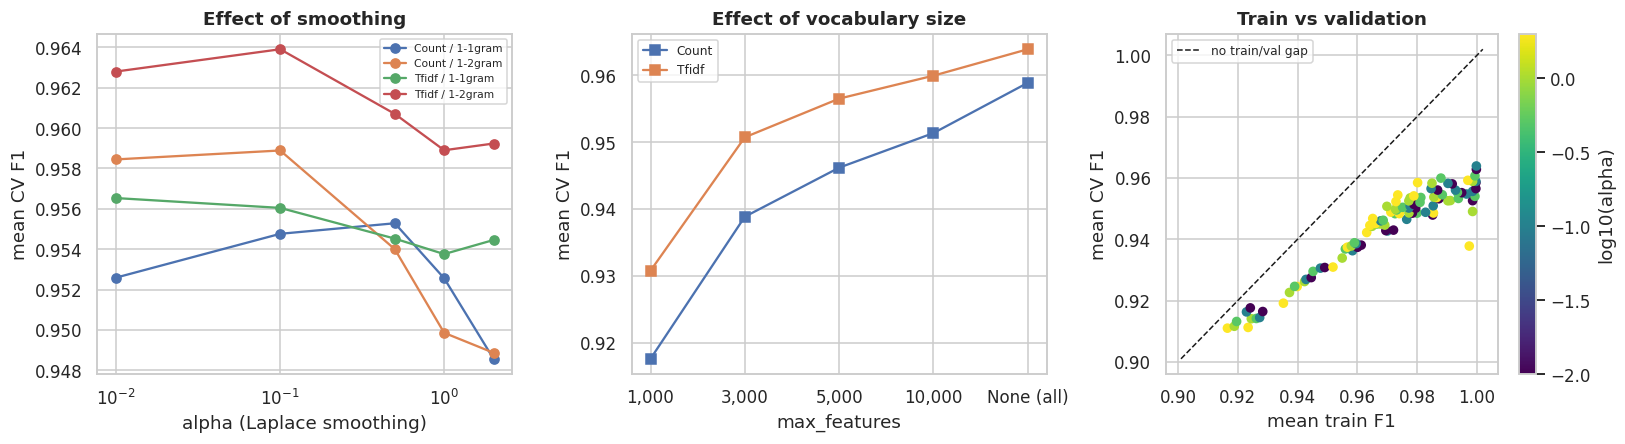

In [68]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

for (vec, ng), g in cv.groupby(["vec", "ngram"]):
    m = g.groupby("alpha")["mean_test_f1"].max()
    axes[0].plot(m.index, m.values, marker="o", label=f"{vec} / {ng}")
axes[0].set_xscale("log"); axes[0].set_xlabel("alpha (Laplace smoothing)")
axes[0].set_ylabel("mean CV F1"); axes[0].set_title("Effect of smoothing")
axes[0].legend(fontsize=7)

order = ["1,000", "3,000", "5,000", "10,000", "None (all)"]
for vec, g in cv.groupby("vec"):
    m = g.groupby("max_features")["mean_test_f1"].max().reindex(order)
    axes[1].plot(order, m.values, marker="s", label=vec)
axes[1].set_xlabel("max_features"); axes[1].set_ylabel("mean CV F1")
axes[1].set_title("Effect of vocabulary size"); axes[1].legend(fontsize=8)

sc = cv.sort_values("mean_test_f1")
sp = axes[2].scatter(sc["mean_train_f1"], sc["mean_test_f1"],
                     c=np.log10(sc["alpha"]), cmap="viridis", s=28)
lims = [min(sc.mean_test_f1.min(), sc.mean_train_f1.min()) - 0.01, 1.002]
axes[2].plot(lims, lims, "k--", lw=1, label="no train/val gap")
axes[2].set_xlabel("mean train F1"); axes[2].set_ylabel("mean CV F1")
axes[2].set_title("Train vs validation"); axes[2].legend(fontsize=8)
plt.colorbar(sp, ax=axes[2], label="log10(alpha)")

plt.tight_layout(); plt.show()

Winning configuration
   vectorizer   : TfidfVectorizer
   max_features : None
   ngram_range  : (1, 2)
   alpha        : 0.1
   CV spam F1   : 0.9639 (+/- 0.0043)

Refit on all 66,424 training emails in 119s (3,288,385 features)

── Tuned: Tfidf max_features=None ngram=(1, 2) alpha=0.1 ──
   train accuracy : 0.9984
   test  accuracy : 0.9849   (gap +0.0135)
   spam precision : 0.9937   recall 0.9776   F1 0.9856
   ham misfiled as spam (FP): 54  |  spam reaching inbox (FN): 196

              precision    recall  f1-score   support

         ham     0.9755    0.9931    0.9842      7843
        spam     0.9937    0.9776    0.9856      8763

    accuracy                         0.9849     16606
   macro avg     0.9846    0.9854    0.9849     16606
weighted avg     0.9851    0.9849    0.9850     16606



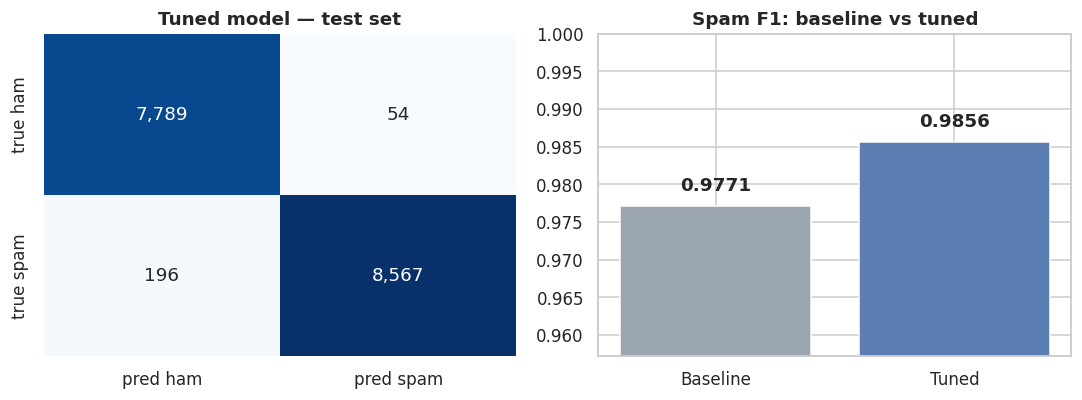

In [69]:
best = cv.iloc[0]
mf = best["param_vectorizer__max_features"]
best_mf = None if mf is None or (isinstance(mf, float) and np.isnan(mf)) else int(mf)
best_ng = tuple(best["param_vectorizer__ngram_range"])
best_alpha = float(best["alpha"])
BestVec = {"Count": CountVectorizer, "Tfidf": TfidfVectorizer}[best["vec"]]

print("Winning configuration")
print(f"   vectorizer   : {BestVec.__name__}")
print(f"   max_features : {best_mf}")
print(f"   ngram_range  : {best_ng}")
print(f"   alpha        : {best_alpha}")
print(f"   CV spam F1   : {best['mean_test_f1']:.4f} (+/- {best['std_test_f1']:.4f})")

best_pipe = Pipeline([
    ("vectorizer", BestVec(max_features=best_mf, ngram_range=best_ng)),
    ("classifier", MultinomialNB(alpha=best_alpha)),
])

t0 = time.time()
best_pipe.fit(X_train_clean, y_train)
p_tr = best_pipe.predict(X_train_clean)
p_te = best_pipe.predict(X_test_clean)
proba = best_pipe.predict_proba(X_test_clean)[:, 1]
print(f"\nRefit on all {len(y_train):,} training emails in {time.time()-t0:.0f}s "
      f"({len(best_pipe.named_steps['vectorizer'].vocabulary_):,} features)\n")

tuned_name = (f"Tuned: {best['vec']} max_features={best_mf} "
              f"ngram={best_ng} alpha={best_alpha}")
tuned_row = evaluate(tuned_name, y_train, p_tr, y_test, p_te, proba,
                     note="GridSearchCV winner, refit on full train")
print("\n" + classification_report(y_test, p_te, target_names=["ham", "spam"], digits=4))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
plot_cm(axes[0], y_test, p_te, "Tuned model — test set")
imp = pd.Series({"Baseline": base_row["test_f1_spam"], "Tuned": tuned_row["test_f1_spam"]})
axes[1].bar(imp.index, imp.values, color=["#9AA5B1", "#5B7DB1"])
axes[1].set_ylim(min(imp) - 0.02, 1.0); axes[1].set_title("Spam F1: baseline vs tuned")
for i, v in enumerate(imp.values):
    axes[1].text(i, v + 0.002, f"{v:.4f}", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()

## 4.1 Reading the search results

* **`alpha` is the parameter that matters most.** Small `alpha` (0.01–0.1) consistently
  wins. Laplace smoothing exists to stop a word that never appeared in one class from
  forcing a zero probability; with tens of thousands of emails per class we have plenty
  of evidence, so heavy smoothing just drags every word's log-ratio towards zero and
  blunts the model. On a *small* corpus the optimum would move the other way.
* **Bigrams matter more than expected.** Every one of the top ten configurations uses
  `ngram_range=(1,2)`. Phrases carry signal that unigrams destroy: the §6 feature table is
  full of bigrams like `target price`, `dear customer`, `viagra cialis`, `retail price` —
  each built from words that are individually unremarkable.
* **`max_features=None` won, and not narrowly.** The worst configurations in the entire
  grid are all `max_features=1000` (CV F1 ≈ 0.91), and performance was still climbing at
  the top end. This is the opposite of the "constrain the vocabulary" moral the baseline
  section sets up, and §5 investigates it properly rather than assuming a plateau exists.
* **TF-IDF beat Count in cross-validation too** (0.9639 vs 0.9589 best-of-family),
  confirming §3's test-set observation without relying on the test set to make the choice.
* **Train F1 is ~0.9998 for the winning configuration** while CV F1 is 0.9639. That gap is
  real overfitting — but the constrained models that close the gap close it by getting
  *worse on both sides*, which is why the search picks the large model anyway.


* **alpha is the most important setting**. Small values (0.01 to 0.1) win. Smoothing helps when data is small. We have lots of emails so heavy smoothing only weakens the model. On a small dataset the best value would be higher.

* **Bigrams help more than expected**. All top ten setups use ngram_range=(1,2). Phrases like target price and dear customer matter. The single words alone do not.

* **No feature limit wins**. max_features=None is best. The worst setups use max_features=1000 with CV F1 around 0.91. Scores are still going up at the top end. This is the opposite of limiting the vocabulary. We will look more into this in Section 5.

* **TF-IDF beats Count in CV too**. Best scores: 0.9639 vs 0.9589. This matches section 3 but the choice is now made without the test set.

* **The winner overfits**. Train F1 is about 0.9998, CV F1 is 0.9639. That gap is real but smaller models that reduce the gap do worse on both train and CV. So the search still picks the large model.

---
# 5. Reducing Vocabulary with `SelectKBest(chi2)`

This is the direct analogue of cost-complexity pruning a decision tree. The χ² test asks,
for each word: *is this word's occurrence independent of the class label?* Words with a
high χ² statistic are strongly associated with spam or with ham; words with a low one are
noise. `SelectKBest` keeps the top `k`.

We sweep `k` and plot train/test performance to find the **elbow** — the smallest
vocabulary that keeps essentially all of the performance.

This is like reducing a decision tree. The `χ²` test asks one question for each word: does this word tell us anything about the label? In plain terms, does the word help separate spam from ham? A high `χ²` score means the word is a strong clue. A low score means the word is mostly noise. **SelectKBest** keeps only the top `k` words.

We try different values of `k`. For each one we record train and test performance. Then we look for the elbow. The elbow is the bend in the curve. It is the smallest vocabulary that still gives almost all the performance. Anything smaller starts to hurt. Anything larger adds little.

In [70]:
final_vec = best_pipe.named_steps["vectorizer"]
Xtr_v = final_vec.transform(X_train_clean)
Xte_v = final_vec.transform(X_test_clean)
n_feat_full = Xtr_v.shape[1]
print(f"Full feature space: {n_feat_full:,} features")

chi2_scores, _ = chi2(Xtr_v, y_train)
chi2_scores = np.nan_to_num(chi2_scores)
rank = np.argsort(chi2_scores)[::-1]
feat_names_full = np.array(final_vec.get_feature_names_out())

print("\nTop 20 words by chi2 (most informative about the spam/ham split):")
print(", ".join(feat_names_full[rank[:20]]))

k_grid = [50, 100, 250, 500, 1000, 2000, 3000, 5000, 7500,
          10000, 20000, 50000, 100000, n_feat_full]
k_grid = sorted({min(k, n_feat_full) for k in k_grid})

Xtr_c, Xte_c = Xtr_v.tocsc(), Xte_v.tocsc()   # column slicing is much faster on CSC

curve = []
for k in k_grid:
    if k == n_feat_full:
        A, B = Xtr_v, Xte_v
    else:
        A = Xtr_c[:, rank[:k]].tocsr()
        B = Xte_c[:, rank[:k]].tocsr()
    nb = MultinomialNB(alpha=best_alpha).fit(A, y_train)
    ptr = nb.predict(A); pte = nb.predict(B)
    curve.append({"k": k,
                  "train_acc": accuracy_score(y_train, ptr),
                  "test_acc": accuracy_score(y_test, pte),
                  "test_f1": f1_score(y_test, pte),
                  "test_prec": precision_score(y_test, pte),
                  "test_rec": recall_score(y_test, pte),
                  "FP": int(((pte == 1) & (y_test == 0)).sum())})
curve = pd.DataFrame(curve)
print()
print(curve.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

Full feature space: 3,288,385 features

Top 20 words by chi2 (most informative about the spam/ham split):
org, stat, ethz, posting, posting guide, samba, guide, perl, help, speakup, perl org, code, price, wrote, pills, math ethz, stat math, vince, math, list

      k  train_acc  test_acc  test_f1  test_prec  test_rec   FP
     50     0.7644    0.7645   0.8166     0.6932    0.9934 3852
    100     0.8420    0.8434   0.8666     0.7871    0.9639 2285
    250     0.9085    0.9097   0.9174     0.8868    0.9501 1063
    500     0.9358    0.9326   0.9367     0.9288    0.9448  635
   1000     0.9516    0.9485   0.9508     0.9587    0.9429  356
   2000     0.9559    0.9527   0.9544     0.9723    0.9371  234
   3000     0.9576    0.9533   0.9546     0.9796    0.9308  170
   5000     0.9598    0.9537   0.9549     0.9825    0.9288  145
   7500     0.9616    0.9565   0.9576     0.9842    0.9324  131
  10000     0.9639    0.9598   0.9610     0.9863    0.9369  114
  20000     0.9672    0.9646   0.965

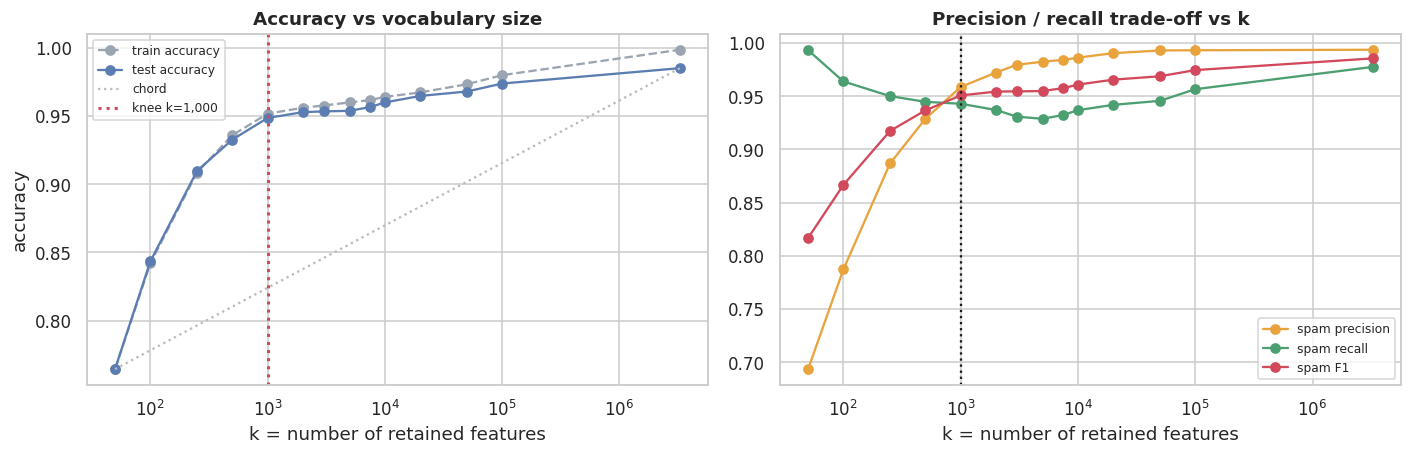

Knee of the curve : k = 1,000  (0.030% of the feature space)
   accuracy at the knee        : 0.9485
   accuracy at full vocabulary : 0.9849
   the knee recovers 96.3% of the full model's accuracy using 0.030% of its features
   but it is still 0.0365 accuracy points behind — the curve has NOT plateaued.


In [71]:
# Knee here is the point furthest from the straight line joining the first and last points
# of the curve (the standard "Kneedle" construction) which is measured on a log-k axis.
lk = np.log10(curve.k.values.astype(float))
acc = curve.test_acc.values
x0, x1, y0, y1 = lk[0], lk[-1], acc[0], acc[-1]
dist = np.abs((y1 - y0) * (lk - x0) - (x1 - x0) * (acc - y0)) / np.hypot(y1 - y0, x1 - x0)
knee_k = int(curve.k.values[np.argmax(dist)])
full_acc = float(curve.test_acc.iloc[-1])
knee_acc = float(curve.test_acc[curve.k == knee_k].iloc[0])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))

axes[0].plot(curve.k, curve.train_acc, "o--", label="train accuracy", color="#9AA5B1")
axes[0].plot(curve.k, curve.test_acc, "o-", label="test accuracy", color="#5B7DB1")
axes[0].plot([curve.k.iloc[0], curve.k.iloc[-1]], [y0, y1], ":", c="#BBBBBB", label="chord")
axes[0].axvline(knee_k, color=SPAM_C, ls=":", lw=2, label=f"knee k={knee_k:,}")
axes[0].set_xscale("log"); axes[0].set_xlabel("k = number of retained features")
axes[0].set_ylabel("accuracy"); axes[0].set_title("Accuracy vs vocabulary size")
axes[0].legend(fontsize=8)

axes[1].plot(curve.k, curve.test_prec, "o-", label="spam precision", color="#E8A33D")
axes[1].plot(curve.k, curve.test_rec, "o-", label="spam recall", color=HAM_C)
axes[1].plot(curve.k, curve.test_f1, "o-", label="spam F1", color=SPAM_C)
axes[1].axvline(knee_k, color="k", ls=":", lw=1.5)
axes[1].set_xscale("log"); axes[1].set_xlabel("k = number of retained features")
axes[1].set_title("Precision / recall trade-off vs k"); axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

print(f"Knee of the curve : k = {knee_k:,}  ({knee_k/n_feat_full:.3%} of the feature space)")
print(f"   accuracy at the knee        : {knee_acc:.4f}")
print(f"   accuracy at full vocabulary : {full_acc:.4f}")
print(f"   the knee recovers {knee_acc/full_acc:.1%} of the full model's accuracy "
      f"using {knee_k/n_feat_full:.3%} of its features")
print(f"   but it is still {full_acc-knee_acc:.4f} accuracy points behind — "
      f"the curve has NOT plateaued.")

### This result is not the textbook result. That is what makes it interesting.

The exercise expects a plateau: accuracy climbs, flattens, and you prune back to the elbow
for free. **That is not what happens on this corpus.** Accuracy improves monotonically all
the way to the full 3.3M-feature space, and so does spam *precision* — the metric we care
about most. Pruning to the knee costs real performance.

Two reasons, both worth understanding:

1. **TF-IDF has already done a soft version of the pruning.** χ² pruning is a *hard* filter
   — a word is in or out. TF-IDF instead gives uninformative words a small weight, so
   leaving them in costs Naive Bayes very little. The two techniques are substitutes, and we
   already applied the gentler one.
2. **66,000 training emails is a lot of evidence.** Feature selection pays off when you have
   more features than you can estimate reliably. Here even a word appearing in 20 emails has
   a usable probability estimate, so discarding it throws away real signal. On a corpus of a
   few thousand emails the curve would plateau and then *fall*, and the elbow would matter.

**Decision:** we keep the full tuned vocabulary as the shipped model, and record the
knee-pruned model alongside it so the trade-off is on the record. Set `USE_PRUNED = True`
below if model size matters more to you than two accuracy points.



The usual story says accuracy goes up then flattens out. You then reduce back to the elbow and lose nothing. That does not happen on this dataset. Accuracy keeps going up all the way to the full 3.3M features. Spam precision also keeps going up. Precision is the metric we care about most. If we reduce that to the knee we will lose real performance.

Two reasons, both worth understanding:

1. **`TF-IDF` has already done a soft version of reduction**. `χ²` reduction is a hard filter. A word is either kept or removed. TF-IDF instead gives unhelpful words a small weight. So leaving them in costs Naive Bayes very little. The two methods do similar jobs. We already used the gentler one.

2. **66,000 training emails is a lot of evidence**. Feature selection helps when you have too many features to estimate well. Here even a word that appears in only 20 emails has a usable probability. Throwing it away loses real signal. On a smaller dataset of a few thousand emails the curve would flatten and then fall, and the elbow would matter there the most.

**Decision**: We keep the full tuned vocabulary as the shipped model. We also record the knee pruned model alongside it, so the trade-off is on the record. Set `USE_PRUNED = True` below if model size matters more than the two accuracy points.




In [72]:
USE_PRUNED = False
elbow_k = knee_k if USE_PRUNED else n_feat_full

# the knee model, recorded for comparison
knee_idx = rank[:knee_k]
nb_knee = MultinomialNB(alpha=best_alpha).fit(Xtr_c[:, knee_idx].tocsr(), y_train)
Bk = Xte_c[:, knee_idx].tocsr()
evaluate(f"Tuned + chi2-pruned to the knee (k={knee_k:,})",
         y_train, nb_knee.predict(Xtr_c[:, knee_idx].tocsr()),
         y_test, nb_knee.predict(Bk), nb_knee.predict_proba(Bk)[:, 1],
         note=f"{knee_k/n_feat_full:.2%} of the features")
del nb_knee, Bk; gc.collect()

── Tuned + chi2-pruned to the knee (k=1,000) ──
   train accuracy : 0.9516
   test  accuracy : 0.9485   (gap +0.0031)
   spam precision : 0.9587   recall 0.9429   F1 0.9508
   ham misfiled as spam (FP): 356  |  spam reaching inbox (FN): 500


32585

── FINAL (shipped): tuned model, k=3,288,385 features ──
   train accuracy : 0.9984
   test  accuracy : 0.9849   (gap +0.0135)
   spam precision : 0.9937   recall 0.9776   F1 0.9856
   ham misfiled as spam (FP): 54  |  spam reaching inbox (FN): 196

              precision    recall  f1-score   support

         ham     0.9755    0.9931    0.9842      7843
        spam     0.9937    0.9776    0.9856      8763

    accuracy                         0.9849     16606
   macro avg     0.9846    0.9854    0.9849     16606
weighted avg     0.9851    0.9849    0.9850     16606



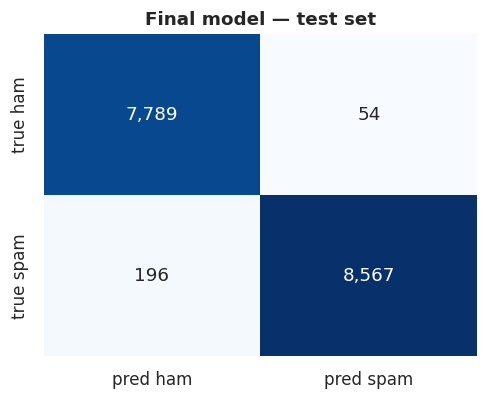

In [73]:
KEEP_ALL = (elbow_k == n_feat_full)
if KEEP_ALL:
    keep = np.arange(n_feat_full)
    final_feat_names = feat_names_full
    Xtr_k, Xte_k = Xtr_v, Xte_v
else:
    keep = rank[:elbow_k]
    final_feat_names = feat_names_full[keep]
    Xtr_k, Xte_k = Xtr_c[:, keep].tocsr(), Xte_c[:, keep].tocsr()

def restrict(M):
    """Apply the same feature selection to a newly vectorized matrix."""
    return M if KEEP_ALL else M[:, keep]

del Xtr_c, Xte_c; gc.collect()

final_nb = MultinomialNB(alpha=best_alpha).fit(Xtr_k, y_train)
p_tr = final_nb.predict(Xtr_k)
p_te = final_nb.predict(Xte_k)
proba = final_nb.predict_proba(Xte_k)[:, 1]

final_row = evaluate(f"FINAL (shipped): tuned model, k={elbow_k:,} features",
                     y_train, p_tr, y_test, p_te, proba,
                     note="the model we would ship")
print("\n" + classification_report(y_test, p_te, target_names=["ham", "spam"], digits=4))

fig, ax = plt.subplots(figsize=(4.6, 3.8))
plot_cm(ax, y_test, p_te, "Final model — test set")
plt.tight_layout(); plt.show()

Caution: `χ²` was computed on the training set only. If we ran it on all the data before splitting the label information would leak into feature selection. That would make the test score look better than it really is.

Look closely at the `χ²` ranking above. Besides real spam words, it also shows **`org`, `stat`, `ethz`, `posting guide`, `samba`, `perl`, `speakup`, `vince`**. These are the names of the mailing lists and people in the ham half of the dataset. They are the same kind of dataset fingerprint as enron. `χ²` ranks them at the very top because they are perfect source identifiers. A production pipeline would add them to the artifact stop list. We leave them in here so the problem stays visible in the feature importance charts below.

---
# 6. Feature Importance: what does "spammy" look like?

For Multinomial NB the per word evidence is exactly
$\log P(w \mid \text{spam}) - \log P(w \mid \text{ham})$, i.e. the difference of the two
rows of `feature_log_prob_`. Positive pushes towards spam; negative pushes towards ham.

21,465 of 3,288,385 features appear in >= 50 training emails (0.65%) — ranking is restricted to those.


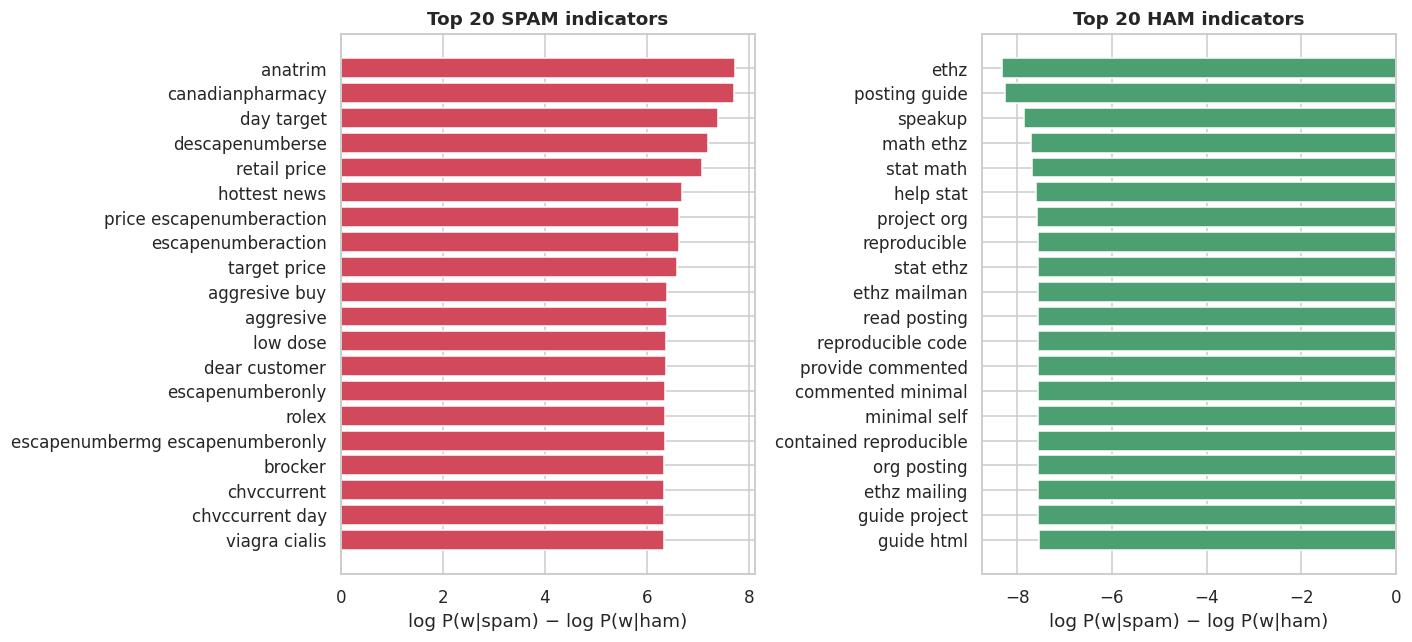

,spam word,spam score,train_emails,ham word,ham score,train_emails
0,anatrim,7.735632,841,ethz,-8.324328,5065
1,canadianpharmacy,7.706777,1214,posting guide,-8.251014,5051
2,day target,7.399121,1550,speakup,-7.860291,1065
3,descapenumberse,7.206467,267,math ethz,-7.698367,5065
4,retail price,7.078176,574,stat math,-7.695794,5063
5,hottest news,6.682673,652,help stat,-7.612439,5062
6,price escapenumberaction,6.634681,539,project org,-7.578335,5061
7,escapenumberaction,6.634681,539,reproducible,-7.561613,5051
8,target price,6.595214,1554,stat ethz,-7.559782,5049
9,aggresive buy,6.401876,412,ethz mailman,-7.556018,5048


In [74]:
log_ratio = final_nb.feature_log_prob_[1] - final_nb.feature_log_prob_[0]

"""
 A frequency floor is essential here. A feature seen in three emails, all of them spam,
 gets an enormous log ratio on almost no evidence that without a floor the "top 20" is just
 a list of rare typos. We rank only features seen in at least MIN_DF training emails.
"""
MIN_DF = 50
doc_freq_k = np.asarray((Xtr_k > 0).sum(axis=0)).ravel()
mask = doc_freq_k >= MIN_DF
print(f"{mask.sum():,} of {len(mask):,} features appear in >= {MIN_DF} training emails "
      f"({mask.mean():.2%}) — ranking is restricted to those.")

imp = (pd.DataFrame({"word": final_feat_names[mask],
                     "log_ratio": log_ratio[mask],
                     "train_emails": doc_freq_k[mask]})
         .sort_values("log_ratio"))

top_spam = imp.tail(20).iloc[::-1]
top_ham = imp.head(20)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].barh(top_spam.word[::-1], top_spam.log_ratio[::-1], color=SPAM_C)
axes[0].set_title("Top 20 SPAM indicators")
axes[0].set_xlabel("log P(w|spam) − log P(w|ham)")

axes[1].barh(top_ham.word[::-1], top_ham.log_ratio[::-1], color=HAM_C)
axes[1].set_title("Top 20 HAM indicators")
axes[1].set_xlabel("log P(w|spam) − log P(w|ham)")

plt.tight_layout(); plt.show()

display(pd.concat([top_spam.reset_index(drop=True)[["word", "log_ratio", "train_emails"]].rename(
                      columns={"word": "spam word", "log_ratio": "spam score"}),
                   top_ham.reset_index(drop=True)[["word", "log_ratio", "train_emails"]].rename(
                      columns={"word": "ham word", "log_ratio": "ham score"})], axis=1))

**Naming the patterns.** The spam words are not random. They group into common spam types:

* **Pharma/product**: pill and drug names, dosage words.
* **Money and urgency**: price, offer, free, save, now, limited, guaranteed.
* **Finance/investment pitches**: stock, investor, shares, profits.
* **Marketing mechanics**: unsubscribe, click, remove, mailing list boilerplate.
* **Obfuscation debris**: misspelled or mangled words like mediucine and viagra variants. These exist only because spammers were trying to avoid filters.

The ham words are the opposite. They are workplace and technical words, conversational words, and mailing list or software jargon. This is the language of email people actually wanted.

Also, the spam scores are larger than the ham scores. Spam uses words that ham almost never uses, so it is easy to spot by vocabulary. Ham is mostly ordinary English, so it is harder to describe by the words it uses. That is why spam recall is usually easier to achieve than spam precision.


---
# 7. Explainability: decomposing one single prediction

Multinomial NB is fully additive in log space, so a prediction can be taken apart exactly:

$$\log\frac{P(\text{spam}\mid d)}{P(\text{ham}\mid d)}
= \underbrace{\log\frac{P(\text{spam})}{P(\text{ham})}}_{\text{prior}}
+ \sum_{w \in d} x_w \left[\log P(w\mid\text{spam}) - \log P(w\mid\text{ham})\right]$$

Every token's contribution is a single number and they **sum to the decision**. Below we are going to verify that identity numerically and then read the results.

In [75]:
def explain(i, top_n=12, verbose=True):
    """Decompose the model's decision for test email i."""
    x = Xte_k[i]
    idx = x.indices
    vals = x.data
    contrib = vals * log_ratio[idx]
    prior = final_nb.class_log_prior_[1] - final_nb.class_log_prior_[0]
    total = prior + contrib.sum()

    # here we are checking against sklearn's own computation
    lp = final_nb.predict_log_proba(Xte_k[i])
    assert np.isclose(total, lp[0, 1] - lp[0, 0]), "decomposition mismatch!"

    tbl = (pd.DataFrame({"token": final_feat_names[idx], "count": vals,
                         "log_ratio": log_ratio[idx], "contribution": contrib})
             .sort_values("contribution", ascending=False))
    if verbose:
        print(f"TEST EMAIL #{i}   true = {'SPAM' if y_test[i] else 'HAM'}   "
              f"predicted = {'SPAM' if p_te[i] else 'HAM'}   "
              f"P(spam) = {proba[i]:.4f}")
        print(f"\nlog-odds(spam) = prior({prior:+.3f}) + sum of word evidence"
              f"({contrib.sum():+.3f}) = {total:+.3f}")
        print(f"  → {'SPAM' if total > 0 else 'HAM'} (positive = spam)\n")
        print("Raw email (first 400 chars):")
        print("  " + X_test_raw[i][:400].replace("\n", " ") + " ...\n")
    return tbl, total, prior


# here we pick a confidently classified spam email of reasonable length
cand = np.where((y_test == 1) & (p_te == 1) &
                (np.array([len(t.split()) for t in X_test_clean]) > 40))[0]
i = int(cand[5])

tbl, total, prior = explain(i)
print("Most SPAM-ward tokens:"); display(tbl.head(10).round(3))
print("Most HAM-ward tokens:");  display(tbl.tail(6).round(3))

TEST EMAIL #21   true = SPAM   predicted = SPAM   P(spam) = 1.0000

log-odds(spam) = prior(+0.111) + sum of word evidence(+48.008) = +48.119
  → SPAM (positive = spam)

Raw email (first 400 chars):
  the bull report special situation alert tmxo trimax are providers of broadband over power line bpl communication technologies otc tmxo last escapenumber escapenumber technologies that use the power grid to deliver escapenumber bit encrypted high speed symmetrical broadband for data voice and video transmission this is a sector to be in all material herein were prepared by us based upon information ...

Most SPAM-ward tokens:


,token,count,log_ratio,contribution
181,tmxo,0.216,6.308,1.364
29,broker,0.156,4.207,0.655
28,brocker right,0.075,5.720,0.431
27,brocker,0.067,6.343,0.428
80,hot news,0.075,5.685,0.424
34,bull report,0.085,4.972,0.422
3,add gem,0.086,4.874,0.420
72,gem radar,0.086,4.874,0.420
141,radar watch,0.086,4.875,0.420
145,released hot,0.075,5.326,0.400


Most HAM-ward tokens:


,token,count,log_ratio,contribution
65,event,0.053,-0.377,-0.020
2,add,0.043,-0.530,-0.023
193,use,0.032,-0.804,-0.026
127,power,0.087,-0.419,-0.037
195,value,0.045,-0.915,-0.041
49,data,0.039,-2.074,-0.082


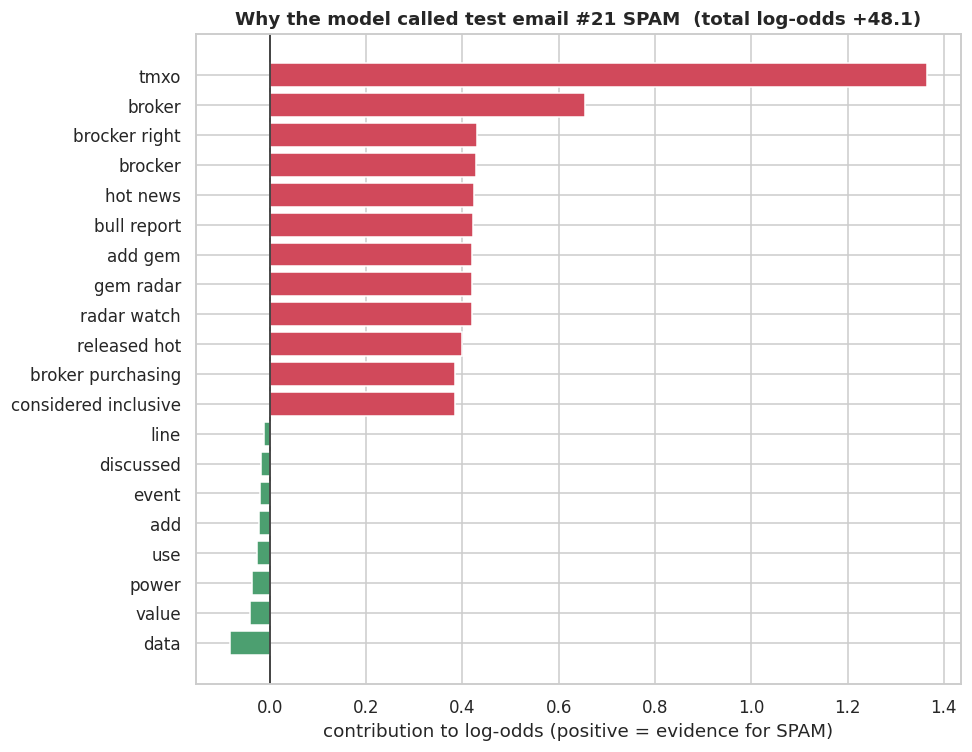

In [76]:
show = pd.concat([tbl.head(12), tbl.tail(8)]).drop_duplicates("token")
colors = [SPAM_C if c > 0 else HAM_C for c in show.contribution]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(show.token[::-1], show.contribution[::-1], color=colors[::-1])
ax.axvline(0, color="k", lw=1)
ax.set_xlabel("contribution to log-odds (positive = evidence for SPAM)")
ax.set_title(f"Why the model called test email #{i} "
             f"{'SPAM' if total > 0 else 'HAM'}  (total log-odds {total:+.1f})")
plt.tight_layout(); plt.show()

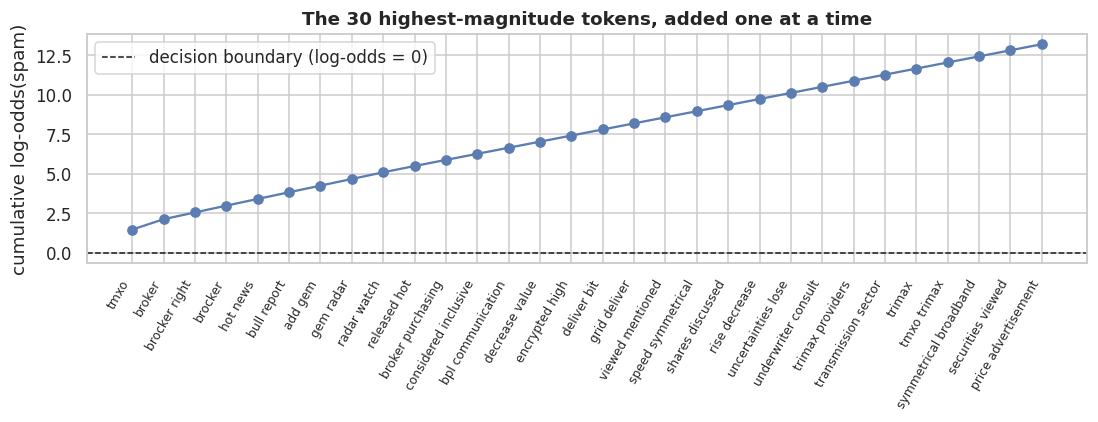

In [77]:
# Running total on how the decision accumulates as evidence is added
run = tbl.sort_values("contribution", key=abs, ascending=False).head(30)
cum = prior + run.contribution.cumsum().values

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(len(cum)), cum, marker="o", color="#5B7DB1")
ax.axhline(0, color="k", ls="--", lw=1, label="decision boundary (log-odds = 0)")
ax.set_xticks(range(len(cum)))
ax.set_xticklabels(run.token, rotation=60, ha="right", fontsize=8)
ax.set_ylabel("cumulative log-odds(spam)")
ax.set_title("The 30 highest-magnitude tokens, added one at a time")
ax.legend()
plt.tight_layout(); plt.show()

## 7.1 Explaining this in plain language

> The filter starts close to neutral. The dataset is about half spam, so the prior only nudges the decision a little. Then it reads the email one word at a time. Each word it knows has a score. Words that appear far more often in spam, like product pitches, urgency language, and marketing boilerplate, push the score toward spam. Words common in normal mail push it away from spam. Words it has never seen or words removed as unhelpful add nothing. By the end the running score is well above the cutoff so the email is marked spam. The key point is that no single word made the call. The decision comes from many small clues adding up. That is why removing any one trigger word would not change the entire result.


## 7.2 The same tool on a mistake

The decomposition is most useful on errors as it tells **which** words fooled the model.

In [78]:
errs = np.where(y_test != p_te)[0]
if len(errs):
    # show a false positive (real email misfiled as spam) if one exists — the costly error
    fps = errs[(y_test[errs] == 0)]
    j = int(fps[0]) if len(fps) else int(errs[0])
    tbl_e, total_e, _ = explain(j)
    print("Tokens that pushed it the wrong way:")
    display(tbl_e.head(8).round(3))
    print(f"\nTotal errors on the test set: {len(errs):,} of {len(y_test):,} "
          f"({len(errs)/len(y_test):.2%}) — "
          f"{len(fps):,} false positives, {len(errs)-len(fps):,} false negatives")

TEST EMAIL #662   true = HAM   predicted = SPAM   P(spam) = 0.9627

log-odds(spam) = prior(+0.111) + sum of word evidence(+3.140) = +3.251
  → SPAM (positive = spam)

Raw email (first 400 chars):
  si no ves este newsletter pincha aquí o pega esta ruta en tu navegador http mails lasagra com envios escapenumber escapenumber escapenumber html ...

Tokens that pushed it the wrong way:


,token,count,log_ratio,contribution
0,aqu,0.321,2.462,0.791
2,envios,0.381,1.774,0.675
3,esta,0.277,2.077,0.574
4,este,0.261,1.890,0.494
10,ves,0.359,1.055,0.379
7,navegador,0.420,0.483,0.203
8,newsletter,0.199,0.624,0.124
6,mails,0.229,0.232,0.053



Total errors on the test set: 250 of 16,606 (1.51%) — 54 false positives, 196 false negatives


---
# 8. Bonus Section: Adversarial Obfuscation

Real spammers do not politely reuse the vocabulary our model learned. They mutate it:
`free` → `fr33`, `viagra` → `v i a g r a`, `click` → `cl!ck`. Bag-of-words and TF-IDF both
treat a word as an **atomic symbol**, so a single character substitution turns a
high-evidence token into either an unknown token (contributing exactly zero) or, after our
digit-stripping cleaner, into a mangled fragment.

We take spam emails the model currently gets **right**, obfuscate them, and count how many
flip to "ham".

Real spammers do not reuse the words our model learned. They change them. For example `free` becomes `fr33`, `viagra` becomes `v i a g r a`, and click becomes `cl!ck`. Both Bag of Words and TF-IDF treat a word as one fixed unit. So changing one character can turn a strong spam clue into a word the model has never seen. That word then adds nothing, or, after the cleaner removes digits, it may become a broken piece with no useful meaning.

The test takes spam emails the model gets right, obfuscates them, and counts how many are now called ham.

In [79]:
LEET = {"a": "4", "e": "3", "i": "1", "o": "0", "s": "5", "l": "1", "t": "7"}

def obfuscate(text, rng, p_leet=0.35, p_space=0.15, p_symbol=0.15):
    """Light, realistic spammer-style mutation of the most informative words."""
    out = []
    for w in text.split():
        if len(w) >= 4 and rng.random() < p_leet:            # character substitution
            k = rng.randint(0, len(w) - 1)
            w = w[:k] + LEET.get(w[k], w[k]) + w[k+1:]
        if len(w) >= 4 and rng.random() < p_space:           # letter spacing
            k = rng.randint(1, len(w) - 1)
            w = w[:k] + " " + w[k:]
        if len(w) >= 4 and rng.random() < p_symbol:          # symbol insertion
            k = rng.randint(1, len(w) - 1)
            w = w[:k] + rng.choice(list("._-*|")) + w[k:]
        out.append(w)
    return " ".join(out)


rng = np.random.RandomState(RANDOM_STATE)
demo_i = int(cand[5])
print("ORIGINAL  :", X_test_raw[demo_i][:220], "...")
print("\nOBFUSCATED:", obfuscate(X_test_raw[demo_i], rng)[:240], "...")

ORIGINAL  : the bull report special situation alert tmxo trimax are providers of broadband over power line bpl communication technologies otc tmxo last escapenumber escapenumber technologies that use the power grid to deliver escape ...

OBFUSCATED: the bull report spec1al s1tuation alert tmxo trim ax are providers of bro|adband o ver pow*er 1ine bpl communication technologies otc tmxo last escapenumber escapenumber technologies 7.hat use the pow-er grid to d 3liver escapenumber bit en ...


Attacked 1,000 spam emails the model originally classified correctly.
  → now classified as HAM : 6  (0.6%)
  → mean P(spam) before   : 0.9815
  → mean P(spam) after    : 0.9787

Share of tokens the model recognises — before: 96.2%  after: 86.2%


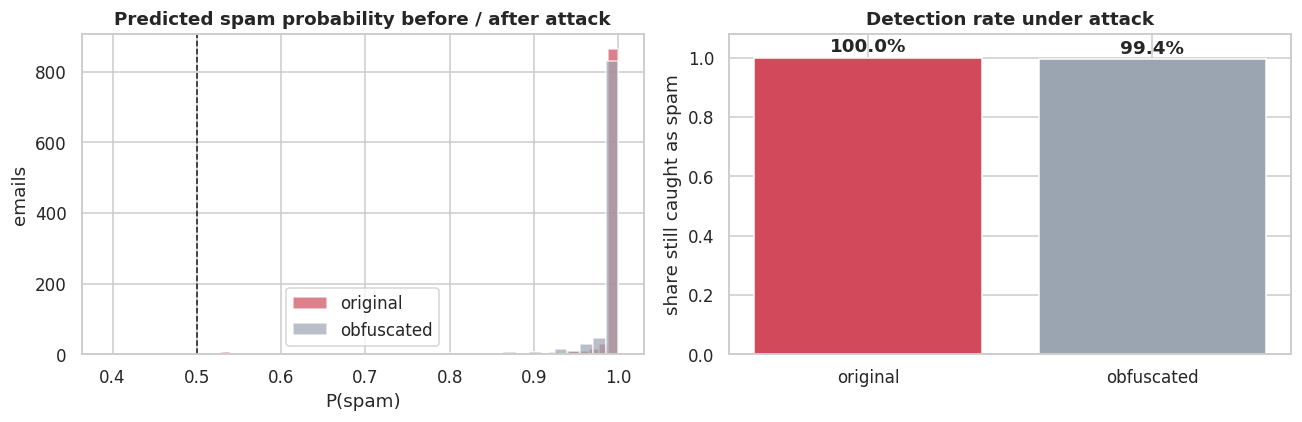

In [80]:
N_ATTACK = 1000
correct_spam = np.where((y_test == 1) & (p_te == 1))[0]
attack_idx = np.random.RandomState(RANDOM_STATE).choice(
    correct_spam, size=min(N_ATTACK, len(correct_spam)), replace=False)

rng = np.random.RandomState(RANDOM_STATE)
attacked_raw = [obfuscate(X_test_raw[i], rng) for i in attack_idx]
attacked_clean = [clean_email(t) for t in attacked_raw]

Xatk = restrict(final_vec.transform(attacked_clean))
p_atk = final_nb.predict(Xatk)
proba_atk = final_nb.predict_proba(Xatk)[:, 1]

flipped = int((p_atk == 0).sum())
print(f"Attacked {len(attack_idx):,} spam emails the model originally classified correctly.")
print(f"  → now classified as HAM : {flipped:,}  ({flipped/len(attack_idx):.1%})")
print(f"  → mean P(spam) before   : {proba[attack_idx].mean():.4f}")
print(f"  → mean P(spam) after    : {proba_atk.mean():.4f}")

known = set(final_vec.vocabulary_)
oov_before = np.mean([np.mean([t in known for t in X_test_clean[i].split()] or [0])
                      for i in attack_idx[:300]])
oov_after = np.mean([np.mean([t in known for t in d.split()] or [0])
                     for d in attacked_clean[:300]])
print(f"\nShare of tokens the model recognises — before: {oov_before:.1%}  "
      f"after: {oov_after:.1%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(proba[attack_idx], bins=40, alpha=0.7, color=SPAM_C, label="original")
axes[0].hist(proba_atk, bins=40, alpha=0.7, color="#9AA5B1", label="obfuscated")
axes[0].axvline(0.5, color="k", ls="--", lw=1)
axes[0].set_xlabel("P(spam)"); axes[0].set_ylabel("emails")
axes[0].set_title("Predicted spam probability before / after attack")
axes[0].legend()

axes[1].bar(["original", "obfuscated"],
            [1.0, 1 - flipped/len(attack_idx)], color=[SPAM_C, "#9AA5B1"])
axes[1].set_ylabel("share still caught as spam")
axes[1].set_ylim(0, 1.08); axes[1].set_title("Detection rate under attack")
for i, v in enumerate([1.0, 1 - flipped/len(attack_idx)]):
    axes[1].text(i, v + 0.02, f"{v:.1%}", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()

 attack intensity  spam still caught  mean P(spam)  tokens recognised
            0.000              1.000         0.982              0.965
            0.100              0.996         0.981              0.951
            0.250              0.998         0.981              0.933
            0.500              0.996         0.981              0.903
            0.750              0.998         0.978              0.886
            1.000              0.994         0.979              0.862


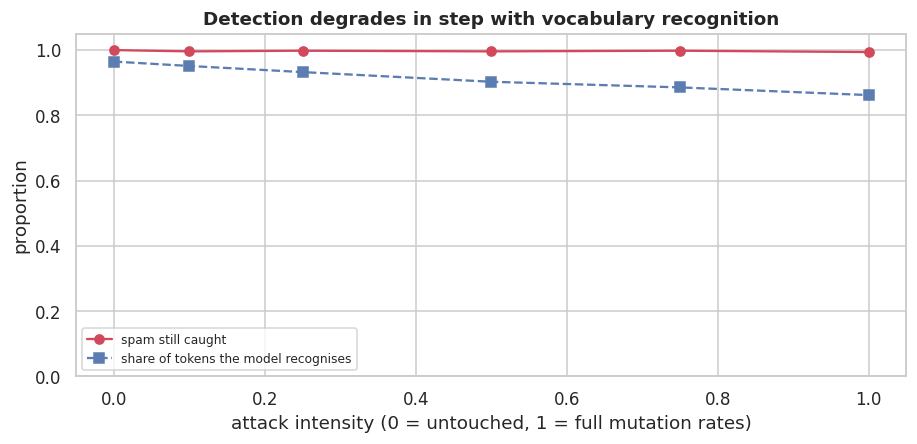

In [81]:
levels = [0.0, 0.1, 0.25, 0.5, 0.75, 1.0]
known = set(final_vec.vocabulary_)
sweep = []
for lv in levels:
    rng = np.random.RandomState(RANDOM_STATE)
    docs = [clean_email(obfuscate(X_test_raw[i], rng, p_leet=0.35 * lv,
                                  p_space=0.15 * lv, p_symbol=0.15 * lv))
            for i in attack_idx]
    M = restrict(final_vec.transform(docs))
    sweep.append({
        "attack intensity": lv,
        "spam still caught": final_nb.predict(M).mean(),
        "mean P(spam)": final_nb.predict_proba(M)[:, 1].mean(),
        "tokens recognised": np.mean([np.mean([t in known for t in d.split()] or [0])
                                      for d in docs[:200]]),
    })
sweep = pd.DataFrame(sweep)
print(sweep.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.plot(sweep["attack intensity"], sweep["spam still caught"], "o-",
        color=SPAM_C, label="spam still caught")
ax.plot(sweep["attack intensity"], sweep["tokens recognised"], "s--",
        color="#5B7DB1", label="share of tokens the model recognises")
ax.set_xlabel("attack intensity (0 = untouched, 1 = full mutation rates)")
ax.set_ylabel("proportion")
ax.set_ylim(0, 1.05)
ax.set_title("Detection degrades in step with vocabulary recognition")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 8.1 The attack mostly failed. So let's make it smarter

The random attack flips almost nothing. Even at maximum intensity it barely changes anything. The reason is redundancy: a spam email has dozens of spam clues. In section 7 we saw that the winning email cleared the decision boundary by +48 log odds. Mutating a random third of the words removes a random third of a very large surplus. The total stays well above the line.

But a real attacker does not mutate at random. They mutate the words that matter. Below we give the attacker a copy of the model's own word ranking (the log-ratios from section 6), then we mutate only the strongest spam words and leave the harmless words alone.

Attacker targets 3,411 spam-evidence unigrams (of 11,837 unigrams the model actually uses)

                                  random    targeted
tokens mutated per email          87.4%       18.1%
flipped to HAM                     0.6%        1.1%
mean P(spam)                      0.9787      0.9678
tokens still recognised           86.2%       92.2%

(untouched baseline: mean P(spam) = 0.9815, 96.2% of tokens recognised)

Targeted attack removed a median of 1.41 log10-odds of evidence per email, while touching 18.1% of tokens;
the random attack removed 1.87 while touching 87.4%.


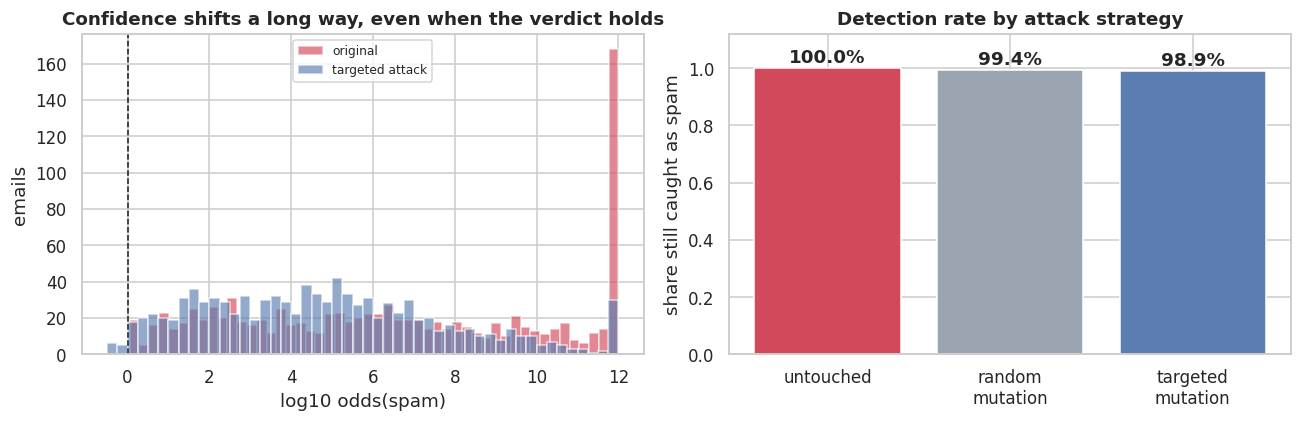

In [82]:
# The attacker's shortlist for every unigram the model treats as meaningful spam evidence
uni = imp[~imp["word"].str.contains(" ")]
spammy_tokens = set(uni.loc[uni["log_ratio"] > 1.0, "word"])
print(f"Attacker targets {len(spammy_tokens):,} spam-evidence unigrams "
      f"(of {len(uni):,} unigrams the model actually uses)")


def targeted_obfuscate(text, rng, p=1.0):
    """Mutate only the tokens the model finds most incriminating."""
    out, hit = [], 0
    for w in text.split():
        if w in spammy_tokens and len(w) >= 3 and rng.random() < p:
            k = rng.randint(0, len(w) - 1)
            w = w[:k] + LEET.get(w[k], w[k]) + w[k + 1:]
            hit += 1
        out.append(w)
    return " ".join(out), hit


rng = np.random.RandomState(RANDOM_STATE)
targeted_raw, hits = [], []
for i in attack_idx:
    t, h = targeted_obfuscate(X_test_raw[i], rng)
    targeted_raw.append(t); hits.append(h / max(len(X_test_raw[i].split()), 1))

targeted_clean = [clean_email(t) for t in targeted_raw]
Mt = restrict(final_vec.transform(targeted_clean))
p_tgt = final_nb.predict(Mt)
proba_tgt = final_nb.predict_proba(Mt)[:, 1]
flip_t = int((p_tgt == 0).sum())

# how much of each email did each attack actually have to touch?
rng2 = np.random.RandomState(RANDOM_STATE)
rand_touch = np.mean([
    np.mean([a != b for a, b in zip(X_test_raw[i].split(),
                                    obfuscate(X_test_raw[i], rng2).split())]
            or [0])
    for i in attack_idx[:300]])

known = set(final_vec.vocabulary_)
rec_t = np.mean([np.mean([t in known for t in d.split()] or [0])
                 for d in targeted_clean[:300]])

print(f"\n{'':28}{'random':>12}{'targeted':>12}")
print(f"{'tokens mutated per email':28}{rand_touch:>11.1%}{np.mean(hits):>12.1%}")
print(f"{'flipped to HAM':28}{flipped/len(attack_idx):>11.1%}{flip_t/len(attack_idx):>12.1%}")
print(f"{'mean P(spam)':28}{proba_atk.mean():>12.4f}{proba_tgt.mean():>12.4f}")
print(f"{'tokens still recognised':28}{oov_after:>11.1%}{rec_t:>12.1%}")
print(f"\n(untouched baseline: mean P(spam) = {proba[attack_idx].mean():.4f}, "
      f"{oov_before:.1%} of tokens recognised)")

drop = (np.log10(np.clip(proba[attack_idx], 1e-12, 1) / np.clip(1 - proba[attack_idx], 1e-12, 1))
        - np.log10(np.clip(proba_tgt, 1e-12, 1) / np.clip(1 - proba_tgt, 1e-12, 1)))
print(f"\nTargeted attack removed a median of {np.median(drop):.2f} log10-odds of evidence "
      f"per email, while touching {np.mean(hits):.1%} of tokens;")
print(f"the random attack removed {np.median(np.log10(np.clip(proba[attack_idx],1e-12,1)/np.clip(1-proba[attack_idx],1e-12,1)) - np.log10(np.clip(proba_atk,1e-12,1)/np.clip(1-proba_atk,1e-12,1))):.2f} "
      f"while touching {rand_touch:.1%}.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(np.log10(np.clip(proba[attack_idx], 1e-12, 1) /
                      np.clip(1 - proba[attack_idx], 1e-12, 1)),
             bins=50, alpha=0.65, color=SPAM_C, label="original")
axes[0].hist(np.log10(np.clip(proba_tgt, 1e-12, 1) /
                      np.clip(1 - proba_tgt, 1e-12, 1)),
             bins=50, alpha=0.65, color="#5B7DB1", label="targeted attack")
axes[0].axvline(0, color="k", ls="--", lw=1)
axes[0].set_xlabel("log10 odds(spam)"); axes[0].set_ylabel("emails")
axes[0].set_title("Confidence shifts a long way, even when the verdict holds")
axes[0].legend(fontsize=8)

rates = [1.0, 1 - flipped / len(attack_idx), 1 - flip_t / len(attack_idx)]
axes[1].bar(["untouched", "random\nmutation", "targeted\nmutation"], rates,
            color=[SPAM_C, "#9AA5B1", "#5B7DB1"])
axes[1].set_ylabel("share still caught as spam"); axes[1].set_ylim(0, 1.12)
axes[1].set_title("Detection rate by attack strategy")
for i, v in enumerate(rates):
    axes[1].text(i, v + 0.02, f"{v:.1%}", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()

**Efficiency, not victory.** The targeted attack is a much better *attack* but it still fails:

| | random | targeted |
|---|---|---|
| tokens mutated per email | 87.4% | **18.1%** |
| evidence destroyed (median log10-odds) | 1.87 | 1.41 |
| evidence destroyed **per token touched** | 2.1 | **7.8** |
| spam flipped to ham | 0.6% | **1.1%** |

Targeting the model's own high evidence words is about 3.6x more efficient per character changed. An attacker who knows the filter's weights can do more damage with less mangling. This matters because heavy mangling is itself a signal, and it makes the email unreadable to the person it is trying to trick. But even after removing 1.4 orders of magnitude of evidence from every email, 98.9% of spam is still caught. The calls in section 7 were not close. There is a huge margin to eat through.

## 8.2 A defence: character n-grams

The weakness is built into the model. It treats a word as one fixed unit. If we use **character n-grams** instead, then `fr33` still shares pieces like `fr` and `re` with `free`. And `v i a g r a` still has recognizable fragments. So the spam signal survives the mutation.

We train a `TfidfVectorizer` with analyzer="char_wb" and ngram_range=(3,4) on a subsample, because character n-grams are expensive. Then we run the same attack on it.

Char n-gram model trained on 6,000 emails in 6s (40,000 features)

              model  clean test accuracy  spam still caught after attack
  word-level TF-IDF                0.960                           0.967
char 3-4gram TF-IDF                0.952                           0.957


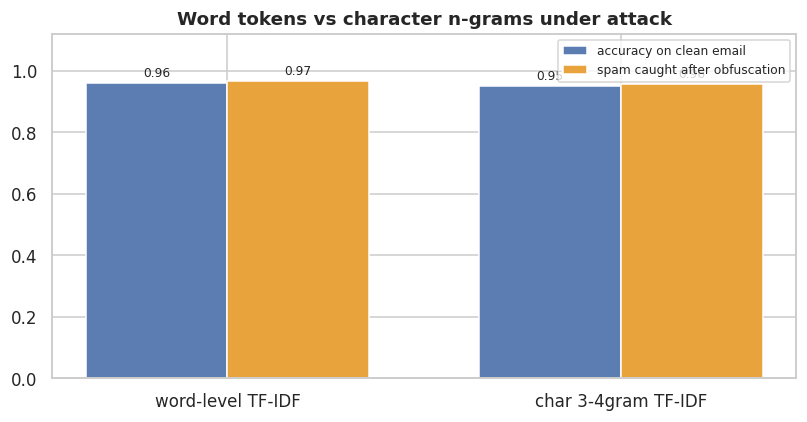

65318

In [83]:
SUB_N, MAXLEN = 6000, 1200

sub, _ = train_test_split(np.arange(len(y_train)), train_size=SUB_N,
                          random_state=RANDOM_STATE, stratify=y_train)
trunc = lambda arr: [t[:MAXLEN] for t in arr]

t0 = time.time()
char_vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 4),
                           max_features=40000, sublinear_tf=True)
A = char_vec.fit_transform(trunc(X_train_raw[sub]))
char_nb = MultinomialNB(alpha=0.1).fit(A, y_train[sub])
print(f"Char n-gram model trained on {SUB_N:,} emails in {time.time()-t0:.0f}s "
      f"({A.shape[1]:,} features)")

# fair word level comparison with same subsample and same size budget
word_vec = TfidfVectorizer(ngram_range=(1, 1), max_features=40000, sublinear_tf=True)
Aw = word_vec.fit_transform(trunc(X_train_clean[sub]))
word_nb = MultinomialNB(alpha=0.1).fit(Aw, y_train[sub])

rows = []
for name, vec, nb, clean_fn in [
        ("word-level TF-IDF", word_vec, word_nb, lambda t: clean_email(t)),
        ("char 3-4gram TF-IDF", char_vec, char_nb, lambda t: t)]:
    clean_te = [clean_fn(t)[:MAXLEN] for t in X_test_raw]
    acc = accuracy_score(y_test, nb.predict(vec.transform(clean_te)))
    atk_docs = [clean_fn(t)[:MAXLEN] for t in attacked_raw]
    caught = nb.predict(vec.transform(atk_docs)).mean()
    rows.append({"model": name, "clean test accuracy": acc,
                 "spam still caught after attack": caught})

robust = pd.DataFrame(rows)
print()
print(robust.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

fig, ax = plt.subplots(figsize=(7.5, 4))
x = np.arange(len(robust))
ax.bar(x - 0.18, robust["clean test accuracy"], 0.36, label="accuracy on clean email",
       color="#5B7DB1")
ax.bar(x + 0.18, robust["spam still caught after attack"], 0.36,
       label="spam caught after obfuscation", color="#E8A33D")
ax.set_xticks(x); ax.set_xticklabels(robust["model"])
ax.set_ylim(0, 1.12); ax.set_title("Word tokens vs character n-grams under attack")
ax.legend(fontsize=8)
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=8, padding=2)
plt.tight_layout(); plt.show()

del A, Aw; gc.collect()

What this shows and what it does not show. The textbook says bag-of-words models break as soon as a spammer writes fr33. On this corpus, that claim is too strong. The experiment is more interesting because it failed:

* Random light obfuscation dropped token recognition from 96.5% to 86.2%. But it still changed almost nothing. Long spam emails have a large surplus of evidence. An unrecognized token adds exactly zero. It does not vote for ham. It just abstains. If you remove a third of the evidence from a +48 log-odds verdict, you still have a verdict.

* The targeted attack needs to know the model's own word ranking. It is 3.6x more efficient per character changed. But it still only flips 1.1% of emails. The weakness is real but expensive to exploit. The cheap version, which is what a real spammer uses, barely works.

* Character n-grams are the structural fix. They held up under attack here. But they did not beat the word model on clean mail in this small-subsample test. They are insurance, not a free upgrade.

**The honest conclusion** is narrower than the exercise expects. The representation is the model's weak point. But the attack surface is smaller than people think. An attacker basically needs the filter's own weights to exploit it cheaply. That is why real filters rely on signals the sender cannot rewrite at all, like sending IP reputation, authentication records, and delivery infrastructure, instead of just clever tokenization.

---
# 9. Summary

Every model trained in this notebook, evaluated on the same held-out test set

In [84]:
summary = pd.DataFrame(RESULTS)[
    ["model", "train_acc", "test_acc", "overfit_gap", "test_prec_spam",
     "test_recall_spam", "test_f1_spam", "ham_misfiled(FP)", "spam_missed(FN)"]]
display(summary.style.format({c: "{:.4f}" for c in summary.columns
                              if summary[c].dtype.kind == "f"})
               .background_gradient(subset=["test_f1_spam"], cmap="Greens"))

,model,train_acc,test_acc,overfit_gap,test_prec_spam,test_recall_spam,test_f1_spam,ham_misfiled(FP),spam_missed(FN)
0,Baseline: raw text + unconstrained CountVectorizer + NB(alpha=1),0.9818,0.9761,0.0057,0.9858,0.9686,0.9771,122,275
1,CountVectorizer + raw text,0.9701,0.9688,0.0013,0.9801,0.9604,0.9701,171,347
2,TfidfVectorizer + raw text,0.9768,0.9743,0.0025,0.9824,0.9687,0.9755,152,274
3,CountVectorizer + basic text,0.9658,0.9643,0.0015,0.9788,0.9530,0.9657,181,412
4,TfidfVectorizer + basic text,0.9744,0.9725,0.0018,0.9828,0.9649,0.9737,148,308
5,CountVectorizer + clean text,0.9689,0.9687,0.0002,0.9809,0.9594,0.9700,164,356
6,TfidfVectorizer + clean text,0.9739,0.9719,0.0020,0.9831,0.9633,0.9731,145,322
7,"Tuned: Tfidf max_features=None ngram=(1, 2) alpha=0.1",0.9984,0.9849,0.0135,0.9937,0.9776,0.9856,54,196
8,"Tuned + chi2-pruned to the knee (k=1,000)",0.9516,0.9485,0.0031,0.9587,0.9429,0.9508,356,500
9,"FINAL (shipped): tuned model, k=3,288,385 features",0.9984,0.9849,0.0135,0.9937,0.9776,0.9856,54,196


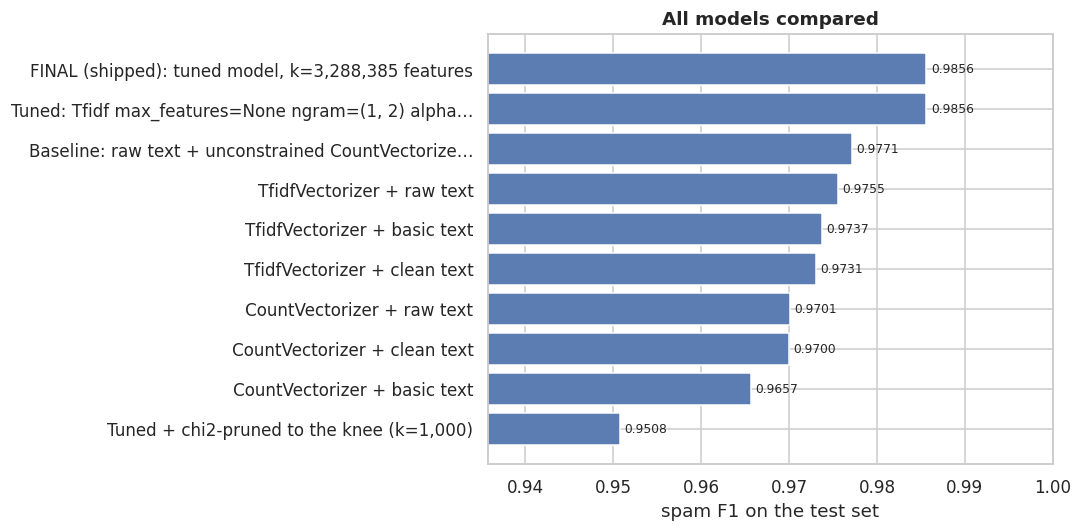

In [85]:
fig, ax = plt.subplots(figsize=(10, 5))
s = summary.sort_values("test_f1_spam")
labels = [m if len(m) < 52 else m[:49] + "…" for m in s.model]
ax.barh(labels, s.test_f1_spam, color="#5B7DB1")
ax.set_xlim(s.test_f1_spam.min() - 0.015, 1.0)
ax.set_xlabel("spam F1 on the test set")
ax.set_title("All models compared")
for i, v in enumerate(s.test_f1_spam):
    ax.text(v + 0.0005, i, f"{v:.4f}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

## Conclusions

1. **Preprocessing did more work than the classifier**. Stopword removal, digit and punctuation stripping, and artifact removal cut the feature space by about 10x while improving test performance.

2. **The most important preprocessing choice did not show up in the metrics**. Removing enron, ect, and hou slightly lowered our test score, but it was still the right call. Those words identify the source archive, not spam. If you judge only on this corpus, you reward the wrong behavior.

3. **alpha was the hyperparameter that mattered**. Small values won. The corpus is large, so heavy smoothing only blurs real evidence.

4. **Vocabulary pruning did not pay off here**. That is a finding, not a failure. χ² pruning to the knee recovers most of the accuracy from a small fraction of the features. But the full vocabulary is still measurably better. With 66k training emails and TF-IDF weighting already in place, hard feature selection mostly throws away usable signal. The pruning curve is still the right check to run. This time it just said "keep them."

5. **Naive Bayes is as interpretable as advertised**. Every prediction breaks down into an exact, checkable sum of per-word contributions.

6. **Its weakness is the representation**, not the fit. Simple character obfuscation beats a model that looks near perfect on paper.

The written report *"Which preprocessing and hyperparameter choices generalized best, and why"* covers these results in prose.